# 08 · Optimización de Pareto por destino y modo de transporte

Este notebook aplica **optimización multiobjetivo de Pareto** al dataset preparado en el notebook 07.

La unidad de análisis es ahora:

> **barrio × destino × modo de transporte**

El modo de transporte **no se incorpora como un objetivo adicional**. En su lugar, el frente de Pareto se calcula de forma independiente para cada combinación **destino–modo**. De esta forma se mantiene el problema principal del TFG:

- minimizar el **precio de referencia de la vivienda**;
- minimizar el **tiempo diario de desplazamiento**;

pero condicionando el segundo objetivo al medio de transporte que utilizaría el usuario.

Los cuatro modos considerados son:

- `TRANSIT`: transporte público;
- `WALK`: desplazamiento a pie;
- `BICYCLE`: bicicleta;
- `CAR`: coche.

Este diseño evita comparar como objetivos simultáneos cuatro tiempos que representan alternativas de movilidad mutuamente excluyentes y permite que el usuario seleccione posteriormente el modo que realmente utilizaría.

Las rutas parciales, los casos `no_route` y las alternativas con precio o tiempo no válido permanecen en el dataset completo del notebook 07, pero **no participan en Pareto**, ya que no disponen de objetivos comparables.


## 1. Importación de librerías


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 180)


## 2. Configuración y localización del proyecto


In [2]:
EXPECTED_MODES = {
    "TRANSIT",
    "WALK",
    "BICYCLE",
    "CAR",
}

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

ALTERNATIVE_KEY = [
    "zone_key",
    "destination_id",
    "transport_mode",
]

PARETO_GROUP_KEY = [
    "destination_id",
    "transport_mode",
]


In [3]:
def find_project_root(
    start: Path | None = None,
) -> Path:
    """Busca la raíz del proyecto a partir de data/ y notebooks/."""

    current = (start or Path.cwd()).resolve()

    for candidate in [
        current,
        *current.parents,
    ]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la carpeta principal del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


In [4]:
PROJECT_ROOT = find_project_root()

FINAL_DIR = PROJECT_ROOT / "data" / "final"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_READY_PATH = (
    FINAL_DIR
    / "neighborhood_recommender_model_ready.csv"
)

COMPLETE_DATASET_PATH = (
    FINAL_DIR
    / "neighborhood_recommender_dataset.csv"
)

PARETO_RESULTS_PATH = (
    RESULTS_DIR
    / "pareto_by_destination_mode.csv"
)

PARETO_FRONT_PATH = (
    RESULTS_DIR
    / "pareto_front_by_destination_mode.csv"
)

PARETO_SUMMARY_PATH = (
    RESULTS_DIR
    / "pareto_summary_by_destination_mode.csv"
)

PARETO_GLOBAL_PATH = (
    RESULTS_DIR
    / "pareto_global_accessibility_by_mode.csv"
)

PARETO_PROFILES_PATH = (
    RESULTS_DIR
    / "pareto_profile_examples_by_destination_mode.csv"
)

PARETO_TRADEOFF_PATH = (
    RESULTS_DIR
    / "pareto_marginal_tradeoffs_by_destination_mode.csv"
)

PARETO_SENSITIVITY_PATH = (
    RESULTS_DIR
    / "pareto_weight_sensitivity_by_destination_mode.csv"
)

PARETO_MODE_SUMMARY_PATH = (
    RESULTS_DIR
    / "pareto_mode_comparison_summary.csv"
)


In [5]:
required_paths = [
    MODEL_READY_PATH,
    COMPLETE_DATASET_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_paths
    )

    raise FileNotFoundError(
        "Faltan archivos generados por el notebook 07:\n"
        f"{formatted_paths}\n"
        "Ejecuta primero el notebook 07 multimodal completo."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset para Pareto:", MODEL_READY_PATH)
print("Carpeta de resultados:", RESULTS_DIR)


Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Dataset para Pareto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\final\neighborhood_recommender_model_ready.csv
Carpeta de resultados: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results


## 3. Carga y contrato de datos

Se cargan dos archivos procedentes del notebook 07:

- `neighborhood_recommender_model_ready.csv`: contiene únicamente alternativas con ruta completa, precio positivo y tiempo diario positivo.
- `neighborhood_recommender_dataset.csv`: conserva también rutas parciales y casos sin itinerario, y se utiliza para auditar qué queda fuera de Pareto.

Antes de continuar se valida explícitamente que el dataset sea multimodal y que la clave lógica **barrio–destino–modo** sea única.


In [6]:
model_data = pd.read_csv(
    MODEL_READY_PATH
)

complete_data = pd.read_csv(
    COMPLETE_DATASET_PATH
)

print(
    "Dataset completo:",
    complete_data.shape,
)

print(
    "Dataset preparado para Pareto:",
    model_data.shape,
)

display(
    model_data.head()
)


Dataset completo: (1572, 152)
Dataset preparado para Pareto: (1457, 152)


,zone_key,neighborhood_name,district_name,has_real_estate_data,price_estimate_available,coverage_status,total_listings,eligible_listings,excluded_listings,eligible_percentage,excluded_percentage,market_share_percentage,num_listings,price_eur_mean,price_eur_median,price_eur_q1,price_eur_q3,price_eur_iqr,price_eur_min,price_eur_max,price_m2_mean,price_m2_median,price_m2_q1,price_m2_q3,price_m2_iqr,price_m2_std,price_m2_relative_iqr_percentage,price_m2_median_ci_low,price_m2_median_ci_high,price_m2_median_ci_width,price_m2_median_ci_relative_width_percentage,price_m2_median_bootstrap_se,bootstrap_sample_size,bootstrap_iterations,bootstrap_confidence_level,bootstrap_status,area_m2_mean,area_m2_median,area_m2_q1,area_m2_q3,area_m2_iqr,area_m2_min,area_m2_max,rooms_mean,rooms_median,rooms_known_count,rooms_unknown_count,rooms_coverage_percentage,bathrooms_mean,bathrooms_median,bathrooms_known_count,bathrooms_unknown_count,bathrooms_coverage_percentage,elevator_ratio,elevator_percentage,elevator_known_count,elevator_unknown_count,elevator_coverage_percentage,exterior_ratio,exterior_percentage,exterior_known_count,exterior_unknown_count,exterior_coverage_percentage,sample_size_score,ci_precision_score,price_homogeneity_score,price_reliability_score,price_reliability_level,price_reliability_reason,market_scope,price_type,source_snapshot_date_status,registered_price_m2_total_2025,registered_price_m2_new_2025,registered_price_m2_used_2025,registered_index_madrid_total_2025,registered_index_madrid_new_2025,registered_index_madrid_used_2025,registered_index_type_total_2025,registered_index_type_new_2025,registered_index_type_used_2025,registered_price_available,registered_new_price_available,registered_used_price_available,reference_year,price_unit,price_statistic,housing_market_scope,source_publisher,source_origin,source_series_code,minimum_cases_to_publish_neighborhood,source_coverage_2025_percentage,kaggle_asking_price_available,kaggle_features_available,kaggle_sample_reliability_score,kaggle_sample_reliability_level,price_m2_for_recommender,price_m2_for_recommender_source,housing_data_availability_status,registered_minus_kaggle_eur_m2,registered_vs_kaggle_gap_percentage,registered_to_kaggle_price_ratio,destination_id,destination_name,transport_mode,transport_mode_label,service_date,morning_requested_datetime,morning_route_status,morning_routing_errors_json,morning_request_error,evening_requested_datetime,evening_route_status,evening_routing_errors_json,evening_request_error,morning_start_datetime,morning_end_datetime,morning_all_modes,morning_transit_modes,morning_routes_used,morning_agencies_used,morning_duration_minutes,morning_distance_meters,morning_walk_time_minutes,morning_waiting_time_minutes,morning_walk_distance_meters,morning_number_of_transfers,evening_start_datetime,evening_end_datetime,evening_all_modes,evening_transit_modes,evening_routes_used,evening_agencies_used,evening_duration_minutes,evening_distance_meters,evening_walk_time_minutes,evening_waiting_time_minutes,evening_walk_distance_meters,evening_number_of_transfers,route_status,route_available,no_route_scenarios,commute_daily_minutes,commute_daily_distance_meters,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_walk_distance_meters,commute_daily_transfers,route_missing_reason,usable_for_pareto_knn,model_readiness_status
0,MAD-011,Palacio,Centro,True,True,available,308,297,11,96.43,3.57,2.67,297,771118.19,540000.0,349000.0,886000.0,537000.0,150000.0,15000000.0,7003.76,6614.32,5789.47,7480.0,1690.53,2142.05,25.56,6462.96,6898.15,435.19,6.58,113.14,297,2000,0.95,calculated,104.48,90.0,50.0,140.0,90.0,25.0,666.0,2.32,2.0,280,17,94.28,1.68,2.0,59,238,19.87,0.7162,71.62,296,1,99.66,0.7306,73.06,297,0,100.0,94.44,91.27,74.21,88.12,high,La estimación presenta una estabilidad alta en...,residential_sale,asking_price,unknown,6895.15,6421.28,6954.58,130.45,127.37,130.39,100,93.13,100.86,True,True,True,2025,EUR_per_m2,mean_declared_transaction_price,resi

In [7]:
required_model_columns = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    "route_status",
    "usable_for_pareto_knn",
    PRICE_COLUMN,
    TIME_COLUMN,
]

required_complete_columns = [
    *required_model_columns,
    "route_available",
]

missing_model_columns = sorted(
    set(required_model_columns)
    - set(model_data.columns)
)

missing_complete_columns = sorted(
    set(required_complete_columns)
    - set(complete_data.columns)
)

if missing_model_columns:
    raise KeyError(
        "Faltan columnas en el dataset model_ready: "
        f"{missing_model_columns}"
    )

if missing_complete_columns:
    raise KeyError(
        "Faltan columnas en el dataset completo: "
        f"{missing_complete_columns}"
    )


In [8]:
# Normalización de claves textuales.

text_columns = [
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    "route_status",
]

for frame in [
    model_data,
    complete_data,
]:
    for column in text_columns:
        frame[column] = (
            frame[column]
            .astype("string")
            .str.strip()
        )

    frame["transport_mode"] = (
        frame["transport_mode"]
        .str.upper()
    )

    frame["route_status"] = (
        frame["route_status"]
        .str.lower()
    )


In [9]:
modes_in_complete = set(
    complete_data[
        "transport_mode"
    ]
    .dropna()
    .unique()
)

missing_modes = sorted(
    EXPECTED_MODES
    - modes_in_complete
)

unexpected_modes = sorted(
    modes_in_complete
    - EXPECTED_MODES
)

if missing_modes:
    raise ValueError(
        "Faltan modos de transporte esperados "
        f"en el dataset completo: {missing_modes}"
    )

if unexpected_modes:
    raise ValueError(
        "Hay modos de transporte no previstos: "
        f"{unexpected_modes}"
    )

mode_labels = (
    complete_data[
        [
            "transport_mode",
            "transport_mode_label",
        ]
    ]
    .drop_duplicates()
    .sort_values("transport_mode")
    .reset_index(drop=True)
)

duplicated_mode_labels = (
    mode_labels
    .groupby("transport_mode")
    ["transport_mode_label"]
    .nunique()
    .gt(1)
)

if duplicated_mode_labels.any():
    raise ValueError(
        "Algún transport_mode tiene más de una etiqueta."
    )

print(
    "Barrios presentes:",
    complete_data["zone_key"].nunique(),
)

print(
    "Destinos presentes:",
    complete_data["destination_id"].nunique(),
)

print(
    "Modos presentes:",
    complete_data["transport_mode"].nunique(),
)

print(
    "Alternativas barrio-destino-modo:",
    len(complete_data),
)

display(mode_labels)


Barrios presentes: 131
Destinos presentes: 3
Modos presentes: 4
Alternativas barrio-destino-modo: 1572


,transport_mode,transport_mode_label
0,BICYCLE,Bicicleta
1,CAR,Coche
2,TRANSIT,Transporte público
3,WALK,A pie


## 4. Validaciones previas

Antes de calcular Pareto se comprueba que:

- no haya alternativas `barrio–destino–modo` duplicadas;
- el precio y el tiempo sean numéricos y positivos en `model_ready`;
- todas las filas utilizadas tengan ruta completa;
- `commute_daily_minutes` coincida con la suma de mañana y tarde cuando ambas columnas estén disponibles;
- el precio de un mismo barrio sea coherente entre modos y destinos, ya que el precio es una propiedad inmobiliaria de la zona y no del medio de transporte.


In [10]:
duplicate_complete = (
    complete_data.loc[
        complete_data.duplicated(
            subset=ALTERNATIVE_KEY,
            keep=False,
        )
    ]
    .sort_values(ALTERNATIVE_KEY)
)

duplicate_model = (
    model_data.loc[
        model_data.duplicated(
            subset=ALTERNATIVE_KEY,
            keep=False,
        )
    ]
    .sort_values(ALTERNATIVE_KEY)
)

print(
    "Alternativas duplicadas en dataset completo:",
    len(duplicate_complete),
)

print(
    "Alternativas duplicadas en model_ready:",
    len(duplicate_model),
)

if not duplicate_complete.empty:
    display(duplicate_complete.head(30))
    raise ValueError(
        "El dataset completo contiene alternativas "
        "barrio-destino-modo duplicadas."
    )

if not duplicate_model.empty:
    display(duplicate_model.head(30))
    raise ValueError(
        "El dataset model_ready contiene alternativas "
        "barrio-destino-modo duplicadas."
    )


Alternativas duplicadas en dataset completo: 0
Alternativas duplicadas en model_ready: 0


In [11]:
for column in [
    PRICE_COLUMN,
    TIME_COLUMN,
]:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce",
    )

invalid_objectives = (
    model_data.loc[
        model_data[
            [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ]
        .isna()
        .any(axis=1)
        |
        (
            model_data[
                [
                    PRICE_COLUMN,
                    TIME_COLUMN,
                ]
            ]
            <= 0
        )
        .any(axis=1)
    ]
    .copy()
)

print(
    "Filas con objetivos no válidos:",
    len(invalid_objectives),
)

if not invalid_objectives.empty:
    display(
        invalid_objectives[
            ALTERNATIVE_KEY
            + [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ]
        .head(30)
    )

    raise ValueError(
        "El dataset model_ready contiene precios "
        "o tiempos ausentes/no positivos."
    )


Filas con objetivos no válidos: 0


In [12]:
def parse_boolean_series(
    series: pd.Series,
) -> pd.Series:
    """Convierte representaciones habituales de booleanos a bool."""

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    valid_true = {
        "true",
        "1",
    }

    valid_false = {
        "false",
        "0",
    }

    invalid_values = (
        ~normalized.isin(
            valid_true
            | valid_false
        )
    )

    if invalid_values.any():
        raise ValueError(
            "Se han encontrado valores no booleanos en "
            "usable_for_pareto_knn: "
            f"{sorted(normalized[invalid_values].unique())}"
        )

    return normalized.isin(
        valid_true
    )


model_usable = parse_boolean_series(
    model_data[
        "usable_for_pareto_knn"
    ]
)

if not model_usable.all():
    raise ValueError(
        "El dataset model_ready contiene filas "
        "no marcadas como utilizables."
    )

if not model_data[
    "route_status"
].eq("complete_route").all():
    raise ValueError(
        "El dataset model_ready contiene rutas "
        "que no están marcadas como complete_route."
    )


In [13]:
duration_columns = [
    "morning_duration_minutes",
    "evening_duration_minutes",
]

if all(
    column in model_data.columns
    for column in duration_columns
):
    morning = pd.to_numeric(
        model_data[
            "morning_duration_minutes"
        ],
        errors="coerce",
    )

    evening = pd.to_numeric(
        model_data[
            "evening_duration_minutes"
        ],
        errors="coerce",
    )

    expected_daily_time = (
        morning
        + evening
    )

    inconsistent_daily_time = (
        ~np.isclose(
            model_data[
                TIME_COLUMN
            ],
            expected_daily_time,
            atol=0.02,
            equal_nan=False,
        )
    )

    print(
        "Tiempos diarios inconsistentes con ida + vuelta:",
        int(
            inconsistent_daily_time.sum()
        ),
    )

    if inconsistent_daily_time.any():
        display(
            model_data.loc[
                inconsistent_daily_time,
                ALTERNATIVE_KEY
                + duration_columns
                + [TIME_COLUMN],
            ]
            .head(30)
        )

        raise ValueError(
            "Se han encontrado tiempos diarios "
            "inconsistentes."
        )
else:
    print(
        "No están disponibles las dos columnas separadas "
        "de mañana y tarde. Se utilizará commute_daily_minutes."
    )


Tiempos diarios inconsistentes con ida + vuelta: 0


In [14]:
# El precio debe ser esencialmente el mismo para un mismo barrio,
# independientemente del destino o modo de transporte.

price_consistency = (
    model_data
    .groupby(
        "zone_key"
    )[PRICE_COLUMN]
    .agg(
        ["min", "max", "count"]
    )
)

price_consistency[
    "spread"
] = (
    price_consistency["max"]
    - price_consistency["min"]
)

inconsistent_price_zones = (
    price_consistency.loc[
        price_consistency[
            "spread"
        ].abs().gt(1e-9)
    ]
)

print(
    "Barrios con precio inconsistente entre alternativas:",
    len(inconsistent_price_zones),
)

if not inconsistent_price_zones.empty:
    display(
        inconsistent_price_zones.head(30)
    )

    raise ValueError(
        "El precio de referencia cambia entre "
        "destinos o modos para algún barrio."
    )


Barrios con precio inconsistente entre alternativas: 0


### 4.1. Auditoría de alternativas excluidas

Pareto utiliza únicamente alternativas comparables. Los casos con ruta parcial, `no_route` o datos inmobiliarios no válidos se mantienen en el dataset completo, pero no se rellenan mediante medias ni tiempos artificiales.

Este control permite distinguir una exclusión metodológicamente justificada de una pérdida accidental de observaciones.


In [15]:
complete_usable = parse_boolean_series(
    complete_data[
        "usable_for_pareto_knn"
    ]
)

route_status_summary = (
    complete_data[
        "route_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "route_status"
    )
    .reset_index(
        name="alternativas"
    )
)

audit_by_mode = (
    complete_data
    .assign(
        usable_bool=complete_usable
    )
    .groupby(
        [
            "transport_mode",
            "transport_mode_label",
            "route_status",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        alternativas=(
            "zone_key",
            "size",
        ),
        utilizables=(
            "usable_bool",
            "sum",
        ),
    )
)

print(
    "Estado global de las alternativas:"
)
display(route_status_summary)

print(
    "\nEstado por modo de transporte:"
)
display(
    audit_by_mode.sort_values(
        [
            "transport_mode",
            "route_status",
        ]
    )
)


Estado global de las alternativas:


C:\Users\clave\AppData\Local\Temp\ipykernel_36252\1881419447.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


,route_status,alternativas
0,complete_route,1462
1,no_route,101
2,partial_route,9



Estado por modo de transporte:


,transport_mode,transport_mode_label,route_status,alternativas,utilizables
0,BICYCLE,Bicicleta,complete_route,390,387
1,BICYCLE,Bicicleta,no_route,3,0
2,CAR,Coche,complete_route,363,363
3,CAR,Coche,no_route,24,0
4,CAR,Coche,partial_route,6,0
5,TRANSIT,Transporte público,complete_route,373,371
6,TRANSIT,Transporte público,no_route,17,0
7,TRANSIT,Transporte público,partial_route,3,0
8,WALK,A pie,complete_route,336,336
9,WALK,A pie,no_route,57,0


In [16]:
model_keys = set(
    map(
        tuple,
        model_data[
            ALTERNATIVE_KEY
        ].itertuples(
            index=False,
            name=None,
        ),
    )
)

complete_usable_keys = set(
    map(
        tuple,
        complete_data.loc[
            complete_usable,
            ALTERNATIVE_KEY,
        ].itertuples(
            index=False,
            name=None,
        ),
    )
)

if model_keys != complete_usable_keys:
    missing_in_model = sorted(
        complete_usable_keys
        - model_keys
    )

    unexpected_in_model = sorted(
        model_keys
        - complete_usable_keys
    )

    print(
        "Primeras claves utilizables ausentes en model_ready:",
        missing_in_model[:20],
    )

    print(
        "Primeras claves inesperadas en model_ready:",
        unexpected_in_model[:20],
    )

    raise ValueError(
        "model_ready no coincide exactamente con "
        "las alternativas marcadas como utilizables "
        "en el dataset completo."
    )

print(
    "Alternativas utilizables auditadas:",
    len(model_keys),
)


Alternativas utilizables auditadas: 1457


In [17]:
pareto_base = (
    model_data
    .copy()
    .reset_index(drop=True)
)

expected_groups = set(
    map(
        tuple,
        complete_data[
            PARETO_GROUP_KEY
        ]
        .drop_duplicates()
        .itertuples(
            index=False,
            name=None,
        ),
    )
)

usable_groups = set(
    map(
        tuple,
        pareto_base[
            PARETO_GROUP_KEY
        ]
        .drop_duplicates()
        .itertuples(
            index=False,
            name=None,
        ),
    )
)

missing_usable_groups = sorted(
    expected_groups
    - usable_groups
)

if missing_usable_groups:
    print(
        "Grupos destino-modo sin ninguna alternativa comparable:",
        missing_usable_groups,
    )

    raise ValueError(
        "Algún grupo destino-modo no dispone de "
        "alternativas utilizables para calcular Pareto."
    )

print(
    "Filas que entrarán en Pareto:",
    len(pareto_base),
)

print(
    "Grupos destino-modo que se analizarán:",
    len(usable_groups),
)


Filas que entrarán en Pareto: 1457
Grupos destino-modo que se analizarán: 12


## 5. Dominancia y frente de Pareto

Una alternativa domina a otra dentro del **mismo destino y modo** cuando:

1. tiene un precio igual o menor;
2. tiene un tiempo diario igual o menor;
3. es estrictamente mejor en al menos uno de los dos objetivos.

Las alternativas no dominadas forman el frente de Pareto.

Por ejemplo, si dos barrios se comparan para ir en bicicleta al mismo destino y uno es simultáneamente más barato y más rápido, el segundo queda dominado. En cambio, no se compara directamente un trayecto en coche con otro en transporte público dentro del mismo frente, porque representan decisiones de movilidad diferentes.


In [18]:
def pareto_mask_minimization(
    values: np.ndarray,
) -> np.ndarray:
    """
    Devuelve True para las filas no dominadas.

    Todos los objetivos deben minimizarse.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    if (
        values.ndim != 2
        or values.shape[1] == 0
    ):
        raise ValueError(
            "values debe ser una matriz 2D "
            "con al menos un objetivo."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            "Pareto ha recibido valores no finitos."
        )

    number_of_rows = len(values)

    is_pareto = np.ones(
        number_of_rows,
        dtype=bool,
    )

    for current_index in range(
        number_of_rows
    ):
        current_values = (
            values[current_index]
        )

        dominates_current = (
            np.all(
                values
                <= current_values,
                axis=1,
            )
            & np.any(
                values
                < current_values,
                axis=1,
            )
        )

        dominates_current[
            current_index
        ] = False

        if dominates_current.any():
            is_pareto[
                current_index
            ] = False

    return is_pareto


In [19]:
def count_dominators(
    values: np.ndarray,
) -> np.ndarray:
    """Cuenta cuántas alternativas dominan a cada fila."""

    values = np.asarray(
        values,
        dtype=float,
    )

    if not np.isfinite(values).all():
        raise ValueError(
            "El cálculo de dominadores ha recibido "
            "valores no finitos."
        )

    counts = np.zeros(
        len(values),
        dtype=int,
    )

    for current_index in range(
        len(values)
    ):
        current_values = (
            values[current_index]
        )

        dominates_current = (
            np.all(
                values
                <= current_values,
                axis=1,
            )
            & np.any(
                values
                < current_values,
                axis=1,
            )
        )

        dominates_current[
            current_index
        ] = False

        counts[
            current_index
        ] = int(
            dominates_current.sum()
        )

    return counts


In [20]:
def min_max_normalize(
    series: pd.Series,
) -> pd.Series:
    """Normaliza una serie entre 0 y 1 sin alterar su índice."""

    minimum = series.min()
    maximum = series.max()
    value_range = (
        maximum
        - minimum
    )

    if np.isclose(
        value_range,
        0,
    ):
        return pd.Series(
            0.0,
            index=series.index,
            dtype=float,
        )

    return (
        series
        - minimum
    ) / value_range


## 6. Cálculo de Pareto por destino y modo

La normalización se realiza **dentro de cada grupo destino–modo**, de modo que el precio y el tiempo se comparan en una escala 0–1 únicamente entre alternativas realmente comparables.

La distancia al punto ideal `(0, 0)` no modifica la pertenencia al frente. Se utiliza solo para ordenar las alternativas Pareto y obtener una referencia equilibrada cuando todavía no se han indicado preferencias personales.


In [21]:
def calculate_pareto_by_destination_mode(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """Calcula Pareto de forma independiente por destino y modo."""

    result_parts = []

    for (
        destination_id,
        transport_mode,
    ), group in data.groupby(
        PARETO_GROUP_KEY,
        sort=True,
    ):
        group = group.copy()

        values = group[
            [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        ].to_numpy(
            dtype=float
        )

        group[
            "is_pareto"
        ] = pareto_mask_minimization(
            values
        )

        group[
            "dominated_by_count"
        ] = count_dominators(
            values
        )

        group[
            "price_normalized"
        ] = min_max_normalize(
            group[
                PRICE_COLUMN
            ]
        )

        group[
            "time_normalized"
        ] = min_max_normalize(
            group[
                TIME_COLUMN
            ]
        )

        group[
            "distance_to_ideal"
        ] = np.sqrt(
            group[
                "price_normalized"
            ] ** 2
            + group[
                "time_normalized"
            ] ** 2
        )

        group[
            "pareto_balance_rank"
        ] = pd.NA

        pareto_indices = (
            group.loc[
                group[
                    "is_pareto"
                ]
            ]
            .sort_values(
                [
                    "distance_to_ideal",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                    "zone_key",
                ]
            )
            .index
        )

        group.loc[
            pareto_indices,
            "pareto_balance_rank",
        ] = range(
            1,
            len(
                pareto_indices
            )
            + 1,
        )

        result_parts.append(
            group
        )

    result = pd.concat(
        result_parts,
        ignore_index=True,
    )

    result[
        "pareto_balance_rank"
    ] = (
        result[
            "pareto_balance_rank"
        ]
        .astype("Int64")
    )

    return result


pareto_results = (
    calculate_pareto_by_destination_mode(
        pareto_base
    )
)

pareto_front = (
    pareto_results.loc[
        pareto_results[
            "is_pareto"
        ]
    ]
    .copy()
    .sort_values(
        [
            "destination_id",
            "transport_mode",
            PRICE_COLUMN,
            TIME_COLUMN,
            "zone_key",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Alternativas analizadas:",
    len(pareto_results),
)

print(
    "Alternativas Pareto:",
    len(pareto_front),
)


Alternativas analizadas: 1457
Alternativas Pareto: 136


## 7. Resumen por destino y modo

Para cada combinación destino–modo se muestran:

- número de alternativas comparadas;
- tamaño y porcentaje del frente;
- barrio más barato;
- barrio con menor tiempo diario;
- alternativa Pareto más próxima al punto ideal.

El barrio más barato puede coincidir entre varios modos porque el precio no depende del transporte. Sin embargo, la disponibilidad de rutas y los tiempos sí cambian, por lo que los frentes pueden ser diferentes.


In [22]:
def build_destination_mode_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    """Genera un resumen por destino y modo de transporte."""

    summary_rows = []

    for (
        destination_id,
        transport_mode,
    ), group in results.groupby(
        PARETO_GROUP_KEY,
        sort=True,
    ):
        destination_name = (
            group[
                "destination_name"
            ]
            .dropna()
            .iloc[0]
        )

        transport_mode_label = (
            group[
                "transport_mode_label"
            ]
            .dropna()
            .iloc[0]
        )

        front = (
            group.loc[
                group[
                    "is_pareto"
                ]
            ]
            .copy()
        )

        cheapest = (
            group.sort_values(
                [
                    PRICE_COLUMN,
                    TIME_COLUMN,
                    "zone_key",
                ]
            )
            .iloc[0]
        )

        fastest = (
            group.sort_values(
                [
                    TIME_COLUMN,
                    PRICE_COLUMN,
                    "zone_key",
                ]
            )
            .iloc[0]
        )

        balanced = (
            front.sort_values(
                [
                    "distance_to_ideal",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                    "zone_key",
                ]
            )
            .iloc[0]
        )

        summary_rows.append(
            {
                "destination_id":
                    destination_id,

                "destination_name":
                    destination_name,

                "transport_mode":
                    transport_mode,

                "transport_mode_label":
                    transport_mode_label,

                "alternatives":
                    len(group),

                "pareto_alternatives":
                    len(front),

                "pareto_percentage":
                    round(
                        100
                        * len(front)
                        / len(group),
                        2,
                    ),

                "cheapest_neighborhood":
                    cheapest[
                        "neighborhood_name"
                    ],

                "cheapest_price_eur_m2":
                    round(
                        cheapest[
                            PRICE_COLUMN
                        ],
                        2,
                    ),

                "cheapest_commute_minutes":
                    round(
                        cheapest[
                            TIME_COLUMN
                        ],
                        2,
                    ),

                "fastest_neighborhood":
                    fastest[
                        "neighborhood_name"
                    ],

                "fastest_commute_minutes":
                    round(
                        fastest[
                            TIME_COLUMN
                        ],
                        2,
                    ),

                "fastest_price_eur_m2":
                    round(
                        fastest[
                            PRICE_COLUMN
                        ],
                        2,
                    ),

                "balanced_neighborhood":
                    balanced[
                        "neighborhood_name"
                    ],

                "balanced_price_eur_m2":
                    round(
                        balanced[
                            PRICE_COLUMN
                        ],
                        2,
                    ),

                "balanced_commute_minutes":
                    round(
                        balanced[
                            TIME_COLUMN
                        ],
                        2,
                    ),
            }
        )

    return (
        pd.DataFrame(
            summary_rows
        )
        .sort_values(
            [
                "destination_id",
                "transport_mode",
            ]
        )
        .reset_index(drop=True)
    )


pareto_summary = (
    build_destination_mode_summary(
        pareto_results
    )
)

display(pareto_summary)


,destination_id,destination_name,transport_mode,transport_mode_label,alternatives,pareto_alternatives,pareto_percentage,cheapest_neighborhood,cheapest_price_eur_m2,cheapest_commute_minutes,fastest_neighborhood,fastest_commute_minutes,fastest_price_eur_m2,balanced_neighborhood,balanced_price_eur_m2,balanced_commute_minutes
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,14,10.85,San Cristóbal,1909.6,94.93,Sol,3.70,7696.61,Puerta del Ángel,4033.30,30.27
1,DEST_001,Puerta del Sol,CAR,Coche,121,14,11.57,San Cristóbal,1909.6,40.53,Justicia,9.22,9541.90,Media Legua,3876.72,20.02
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,13,10.92,San Cristóbal,1909.6,139.72,Recoletos,56.37,14108.83,Puerta del Ángel,4033.30,65.13
3,DEST_001,Puerta del Sol,WALK,A pie,128,16,12.50,San Cristóbal,1909.6,264.62,Sol,3.70,7696.61,Puerta del Ángel,4033.30,79.72
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,16,12.40,San Cristóbal,1909.6,142.07,El Viso,10.50,9382.09,Berruguete,4789.99,28.22
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,18,14.88,San Cristóbal,1909.6,42.53,Cuatro Caminos,5.98,6496.82,Berruguete,4789.99,13.35
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,10,8.06,San Cristóbal,1909.6,174.28,Almagro,44.97,10795.41,Rejas,3580.16,82.27
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,18,13.95,San Cristóbal,1909.6,366.12,El Viso,21.03,9382.09,Berruguete,4789.99,61.13
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,4,3.10,San Cristóbal,1909.6,79.53,Cuatro Vientos,50.48,4673.53,Villaverde Alto - Casco Histórico de Villaverde,2928.26,58.68
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,4,3.31,San Cristóbal,1909.6,28.10,Buenavista,16.02,3291.57,Abrantes,2912.90,19.82


In [23]:
for (
    destination_name,
    transport_mode_label,
), group in pareto_summary.groupby(
    [
        "destination_name",
        "transport_mode_label",
    ],
    sort=True,
):
    row = group.iloc[0]

    display(
        Markdown(
            f"""
### {destination_name} · {transport_mode_label}

Se comparan **{int(row['alternatives'])} barrios** con datos válidos para este modo. **{int(row['pareto_alternatives'])} alternativas** forman el frente de Pareto, aproximadamente un **{row['pareto_percentage']:.2f} %** del total.

- **Más barato:** {row['cheapest_neighborhood']} — **{row['cheapest_price_eur_m2']:,.2f} €/m²**, con **{row['cheapest_commute_minutes']:.2f} min/día**.
- **Más rápido:** {row['fastest_neighborhood']} — **{row['fastest_commute_minutes']:.2f} min/día**, con **{row['fastest_price_eur_m2']:,.2f} €/m²**.
- **Referencia equilibrada del frente:** {row['balanced_neighborhood']} — **{row['balanced_price_eur_m2']:,.2f} €/m²** y **{row['balanced_commute_minutes']:.2f} min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.
"""
        )
    )



### Nuevos Ministerios · A pie

Se comparan **129 barrios** con datos válidos para este modo. **18 alternativas** forman el frente de Pareto, aproximadamente un **13.95 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **366.12 min/día**.
- **Más rápido:** El Viso — **21.03 min/día**, con **9,382.09 €/m²**.
- **Referencia equilibrada del frente:** Berruguete — **4,789.99 €/m²** y **61.13 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### Nuevos Ministerios · Bicicleta

Se comparan **129 barrios** con datos válidos para este modo. **16 alternativas** forman el frente de Pareto, aproximadamente un **12.40 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **142.07 min/día**.
- **Más rápido:** El Viso — **10.50 min/día**, con **9,382.09 €/m²**.
- **Referencia equilibrada del frente:** Berruguete — **4,789.99 €/m²** y **28.22 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### Nuevos Ministerios · Coche

Se comparan **121 barrios** con datos válidos para este modo. **18 alternativas** forman el frente de Pareto, aproximadamente un **14.88 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **42.53 min/día**.
- **Más rápido:** Cuatro Caminos — **5.98 min/día**, con **6,496.82 €/m²**.
- **Referencia equilibrada del frente:** Berruguete — **4,789.99 €/m²** y **13.35 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### Nuevos Ministerios · Transporte público

Se comparan **124 barrios** con datos válidos para este modo. **10 alternativas** forman el frente de Pareto, aproximadamente un **8.06 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **174.28 min/día**.
- **Más rápido:** Almagro — **44.97 min/día**, con **10,795.41 €/m²**.
- **Referencia equilibrada del frente:** Rejas — **3,580.16 €/m²** y **82.27 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### Puerta del Sol · A pie

Se comparan **128 barrios** con datos válidos para este modo. **16 alternativas** forman el frente de Pareto, aproximadamente un **12.50 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **264.62 min/día**.
- **Más rápido:** Sol — **3.70 min/día**, con **7,696.61 €/m²**.
- **Referencia equilibrada del frente:** Puerta del Ángel — **4,033.30 €/m²** y **79.72 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.


...


### Puerta del Sol · Transporte público

Se comparan **119 barrios** con datos válidos para este modo. **13 alternativas** forman el frente de Pareto, aproximadamente un **10.92 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **139.72 min/día**.
- **Más rápido:** Recoletos — **56.37 min/día**, con **14,108.83 €/m²**.
- **Referencia equilibrada del frente:** Puerta del Ángel — **4,033.30 €/m²** y **65.13 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### UC3M Campus de Leganés · A pie

Se comparan **79 barrios** con datos válidos para este modo. **4 alternativas** forman el frente de Pareto, aproximadamente un **5.06 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **213.57 min/día**.
- **Más rápido:** Buenavista — **142.93 min/día**, con **3,291.57 €/m²**.
- **Referencia equilibrada del frente:** Villaverde Alto - Casco Histórico de Villaverde — **2,928.26 €/m²** y **149.83 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### UC3M Campus de Leganés · Bicicleta

Se comparan **129 barrios** con datos válidos para este modo. **4 alternativas** forman el frente de Pareto, aproximadamente un **3.10 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **79.53 min/día**.
- **Más rápido:** Cuatro Vientos — **50.48 min/día**, con **4,673.53 €/m²**.
- **Referencia equilibrada del frente:** Villaverde Alto - Casco Histórico de Villaverde — **2,928.26 €/m²** y **58.68 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### UC3M Campus de Leganés · Coche

Se comparan **121 barrios** con datos válidos para este modo. **4 alternativas** forman el frente de Pareto, aproximadamente un **3.31 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **28.10 min/día**.
- **Más rápido:** Buenavista — **16.02 min/día**, con **3,291.57 €/m²**.
- **Referencia equilibrada del frente:** Abrantes — **2,912.90 €/m²** y **19.82 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.



### UC3M Campus de Leganés · Transporte público

Se comparan **128 barrios** con datos válidos para este modo. **5 alternativas** forman el frente de Pareto, aproximadamente un **3.91 %** del total.

- **Más barato:** San Cristóbal — **1,909.60 €/m²**, con **136.33 min/día**.
- **Más rápido:** Buenavista — **51.62 min/día**, con **3,291.57 €/m²**.
- **Referencia equilibrada del frente:** Buenavista — **3,291.57 €/m²** y **51.62 min/día**.

La referencia equilibrada es descriptiva. La recomendación personalizada se realizará posteriormente utilizando las preferencias y restricciones introducidas por el usuario.


### 7.1. Comparación descriptiva entre modos

Esta tabla **no construye un frente mezclando modos**. Su finalidad es únicamente mostrar cómo cambia la distribución de tiempos y la cobertura del dataset utilizable según el medio de transporte.

Esto permite comprobar la aportación de la extensión multimodal sin alterar la formulación de Pareto.


In [24]:
mode_comparison_summary = (
    pareto_results
    .groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        alternatives=(
            "zone_key",
            "size",
        ),
        neighborhoods=(
            "zone_key",
            "nunique",
        ),
        median_commute_daily_minutes=(
            TIME_COLUMN,
            "median",
        ),
        mean_commute_daily_minutes=(
            TIME_COLUMN,
            "mean",
        ),
        minimum_commute_daily_minutes=(
            TIME_COLUMN,
            "min",
        ),
        maximum_commute_daily_minutes=(
            TIME_COLUMN,
            "max",
        ),
        pareto_alternatives=(
            "is_pareto",
            "sum",
        ),
    )
)

numeric_mode_columns = (
    mode_comparison_summary
    .select_dtypes(
        include="number"
    )
    .columns
)

mode_comparison_summary[
    numeric_mode_columns
] = (
    mode_comparison_summary[
        numeric_mode_columns
    ]
    .round(2)
)

display(
    mode_comparison_summary.sort_values(
        [
            "destination_id",
            "transport_mode",
        ]
    )
)


,destination_id,destination_name,transport_mode,transport_mode_label,alternatives,neighborhoods,median_commute_daily_minutes,mean_commute_daily_minutes,minimum_commute_daily_minutes,maximum_commute_daily_minutes,pareto_alternatives
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,129,68.35,73.55,3.70,183.95,14
1,DEST_001,Puerta del Sol,CAR,Coche,121,121,25.17,25.48,9.22,63.85,14
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,119,117.60,118.30,56.37,244.52,13
3,DEST_001,Puerta del Sol,WALK,A pie,128,128,168.92,177.06,3.70,435.82,16
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,129,75.62,76.54,10.50,164.62,16
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,121,25.08,24.43,5.98,65.22,18
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,124,120.80,121.02,44.97,275.78,10
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,129,192.80,195.32,21.03,465.92,18
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,129,174.52,168.37,50.48,299.28,4
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,121,38.37,38.05,16.02,76.82,4


## 8. Tabla detallada del frente y coste marginal

Se añade un precio orientativo para una vivienda de **80 m²** únicamente como transformación del precio por metro cuadrado. No representa una tasación ni incorpora impuestos, gastos, estado de conservación o reformas.

Después, dentro de cada frente destino–modo, las alternativas se ordenan de menor a mayor precio para medir cuánto aumenta el precio de referencia al reducir el tiempo diario de desplazamiento.


In [25]:
pareto_front[
    "reference_price_80m2_eur"
] = (
    pareto_front[
        PRICE_COLUMN
    ]
    * 80
)

front_display_columns = [
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    "neighborhood_name",
    "district_name",
    PRICE_COLUMN,
    "reference_price_80m2_eur",
    TIME_COLUMN,
]

optional_front_columns = [
    "morning_duration_minutes",
    "evening_duration_minutes",
    "commute_daily_distance_meters",
    "commute_daily_walk_minutes",
    "commute_daily_waiting_minutes",
    "commute_daily_transfers",
    "price_m2_for_recommender_source",
    "housing_data_availability_status",
    "kaggle_sample_reliability_level",
    "pareto_balance_rank",
]

front_display_columns += [
    column
    for column in optional_front_columns
    if column in pareto_front.columns
]

pareto_front_table = (
    pareto_front[
        front_display_columns
    ]
    .copy()
)

for column in (
    pareto_front_table
    .select_dtypes(
        include="number"
    )
    .columns
):
    pareto_front_table[
        column
    ] = (
        pareto_front_table[
            column
        ]
        .round(2)
    )

display(
    pareto_front_table
)


,destination_name,transport_mode,transport_mode_label,neighborhood_name,district_name,price_m2_for_recommender,reference_price_80m2_eur,commute_daily_minutes,morning_duration_minutes,evening_duration_minutes,commute_daily_distance_meters,commute_daily_walk_minutes,commute_daily_waiting_minutes,commute_daily_transfers,price_m2_for_recommender_source,housing_data_availability_status,kaggle_sample_reliability_level,pareto_balance_rank
0,Puerta del Sol,BICYCLE,Bicicleta,San Cristóbal,Villaverde,1909.60,152768.0,94.93,46.62,48.32,22659.72,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,14
1,Puerta del Sol,BICYCLE,Bicicleta,Orcasitas,Usera,2357.51,188600.8,73.72,36.40,37.32,18086.68,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,11
2,Puerta del Sol,BICYCLE,Bicicleta,Entrevías,Puente de Vallecas,2430.16,194412.8,71.57,35.05,36.52,17827.99,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,10
3,Puerta del Sol,BICYCLE,Bicicleta,Portazgo,Puente de Vallecas,2703.76,216300.8,70.83,36.35,34.48,15152.15,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,9
4,Puerta del Sol,BICYCLE,Bicicleta,San Fermín,Usera,2755.18,220414.4,56.98,27.87,29.12,13864.93,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,6
5,Puerta del Sol,BICYCLE,Bicicleta,Abrantes,Carabanchel,2912.90,233032.0,56.27,29.03,27.23,12580.50,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,5
6,Puerta del Sol,BICYCLE,Bicicleta,Zofío,Usera,3089.05,247124.0,54.10,27.52,26.58,11672.54,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,4
7,Puerta del Sol,BICYCLE,Bicicleta,Opañel,Carabanchel,3500.89,280071.2,43.23,22.65,20.58,9191.56,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,3
8,Puerta del Sol,BICYCLE,Bicicleta,Moscardó,Usera,3739.18,299134.4,40.90,20.62,20.28,8982.35,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,low,2
9,Puerta del Sol,BICYCLE,Bicicleta,Puerta del Ángel,Latina,4033.30,322664.0,30.27,14.75,15.52,6021.72,0.00,0.00,0.0,registered_transactions_2025,official_price_and_kaggle_features,medium,1


In [26]:
tradeoff_parts = []

for (
    destination_id,
    transport_mode,
), front in pareto_front.groupby(
    PARETO_GROUP_KEY,
    sort=True,
):
    ordered_front = (
        front.sort_values(
            [
                PRICE_COLUMN,
                TIME_COLUMN,
                "zone_key",
            ]
        )
        .copy()
        .reset_index(drop=True)
    )

    ordered_front[
        "extra_price_eur_m2_vs_previous"
    ] = (
        ordered_front[
            PRICE_COLUMN
        ]
        .diff()
    )

    ordered_front[
        "daily_minutes_saved_vs_previous"
    ] = (
        -ordered_front[
            TIME_COLUMN
        ]
        .diff()
    )

    ordered_front[
        "extra_reference_price_80m2_vs_previous_eur"
    ] = (
        ordered_front[
            "extra_price_eur_m2_vs_previous"
        ]
        * 80
    )

    saved_minutes = (
        ordered_front[
            "daily_minutes_saved_vs_previous"
        ]
    )

    ordered_front[
        "extra_reference_price_80m2_per_daily_minute_saved"
    ] = np.where(
        saved_minutes.gt(0),
        ordered_front[
            "extra_reference_price_80m2_vs_previous_eur"
        ]
        / saved_minutes,
        np.nan,
    )

    tradeoff_parts.append(
        ordered_front
    )

marginal_tradeoffs = (
    pd.concat(
        tradeoff_parts,
        ignore_index=True,
    )
)

tradeoff_display_columns = [
    "destination_name",
    "transport_mode_label",
    "neighborhood_name",
    "district_name",
    PRICE_COLUMN,
    TIME_COLUMN,
    "extra_price_eur_m2_vs_previous",
    "daily_minutes_saved_vs_previous",
    "extra_reference_price_80m2_vs_previous_eur",
    "extra_reference_price_80m2_per_daily_minute_saved",
]

display(
    marginal_tradeoffs[
        tradeoff_display_columns
    ]
    .round(2)
)


,destination_name,transport_mode_label,neighborhood_name,district_name,price_m2_for_recommender,commute_daily_minutes,extra_price_eur_m2_vs_previous,daily_minutes_saved_vs_previous,extra_reference_price_80m2_vs_previous_eur,extra_reference_price_80m2_per_daily_minute_saved
0,Puerta del Sol,Bicicleta,San Cristóbal,Villaverde,1909.60,94.93,NaN,NaN,NaN,NaN
1,Puerta del Sol,Bicicleta,Orcasitas,Usera,2357.51,73.72,447.91,21.22,35832.8,1688.90
2,Puerta del Sol,Bicicleta,Entrevías,Puente de Vallecas,2430.16,71.57,72.65,2.15,5812.0,2703.26
3,Puerta del Sol,Bicicleta,Portazgo,Puente de Vallecas,2703.76,70.83,273.60,0.73,21888.0,29847.27
4,Puerta del Sol,Bicicleta,San Fermín,Usera,2755.18,56.98,51.42,13.85,4113.6,297.01
5,Puerta del Sol,Bicicleta,Abrantes,Carabanchel,2912.90,56.27,157.72,0.72,12617.6,17605.95
6,Puerta del Sol,Bicicleta,Zofío,Usera,3089.05,54.10,176.15,2.17,14092.0,6504.00
7,Puerta del Sol,Bicicleta,Opañel,Carabanchel,3500.89,43.23,411.84,10.87,32947.2,3031.95
8,Puerta del Sol,Bicicleta,Moscardó,Usera,3739.18,40.90,238.29,2.33,19063.2,8169.94
9,Puerta del Sol,Bicicleta,Puerta del Ángel,Latina,4033.30,30.27,294.12,10.63,23529.6,2212.82


## 9. Representación gráfica de los frentes

Se genera un gráfico independiente para cada combinación **destino–modo**.

- Eje X: precio de referencia por m².
- Eje Y: minutos diarios de desplazamiento.
- Los puntos dominados muestran alternativas claramente peores bajo estos dos objetivos.
- El frente une las alternativas eficientes.

Las etiquetas se limitan a las alternativas Pareto más próximas al punto ideal para mantener la legibilidad.


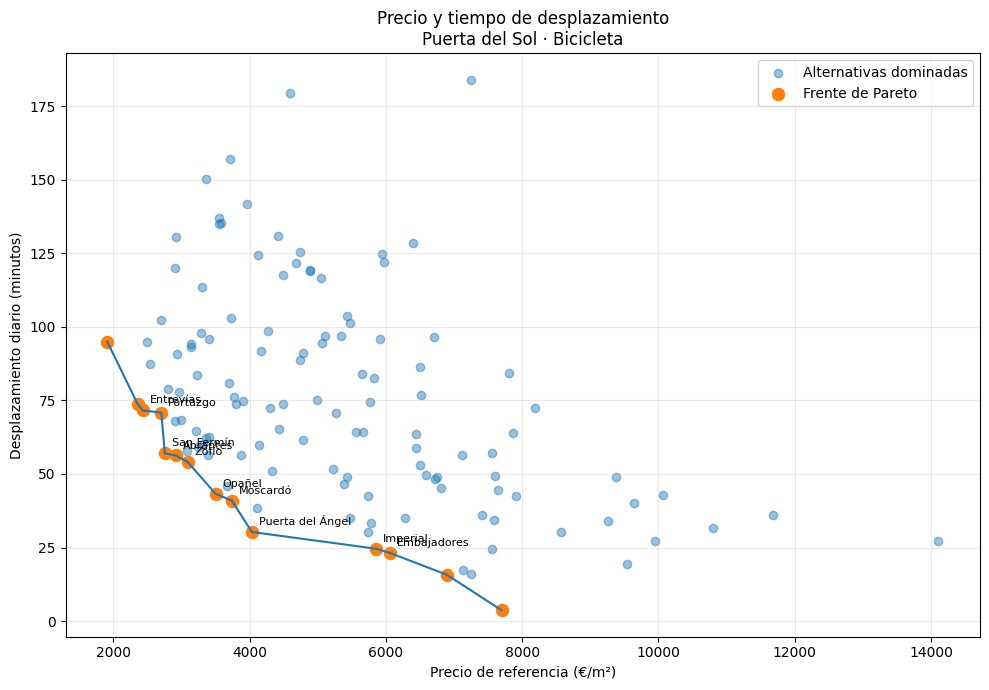

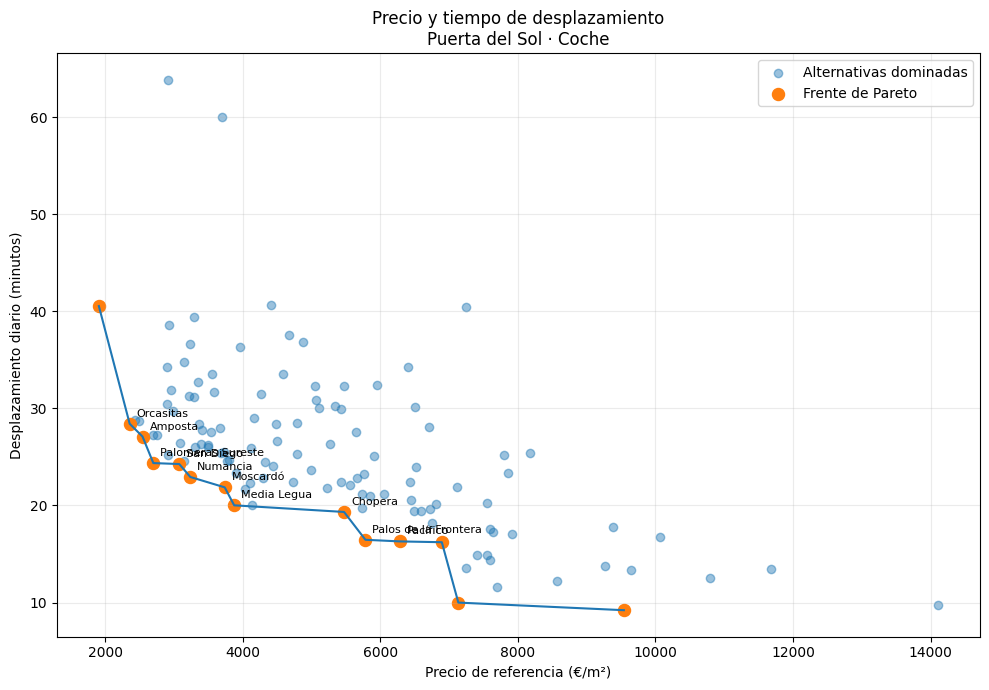

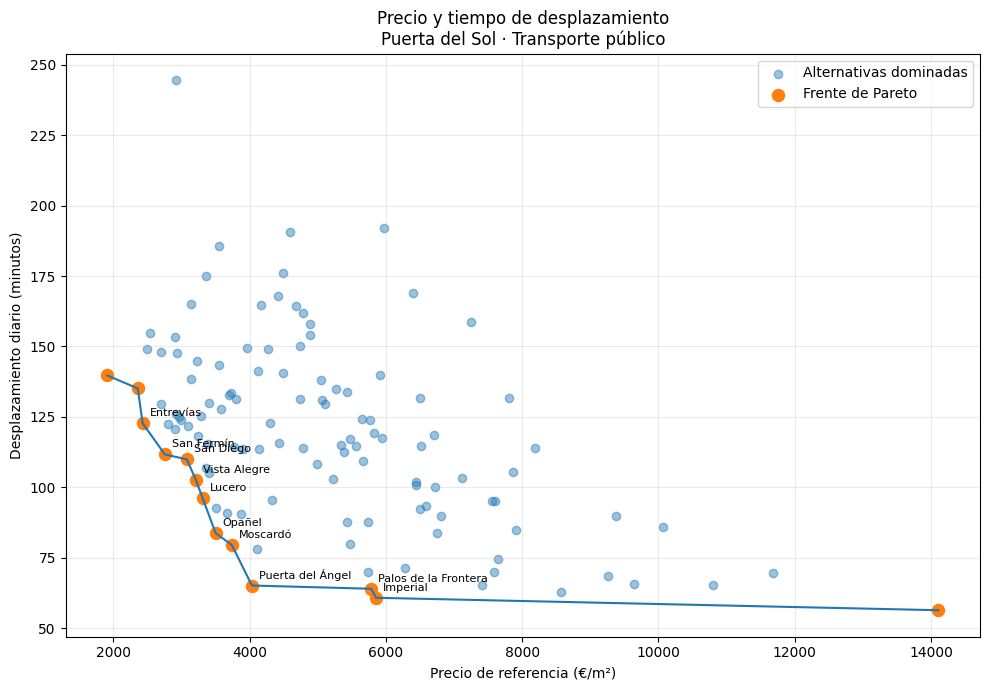

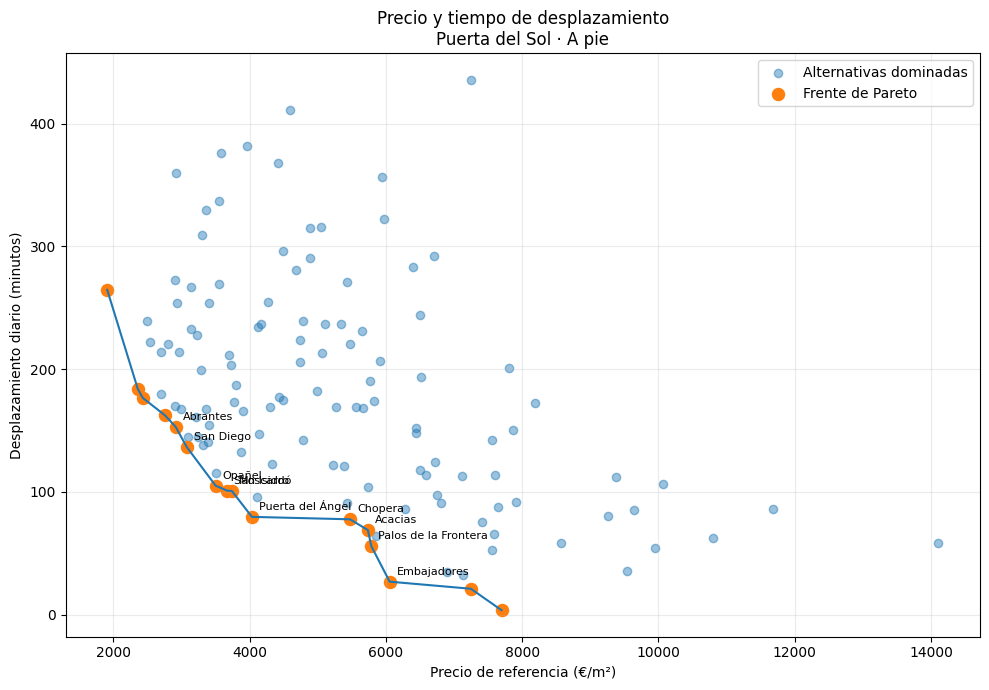

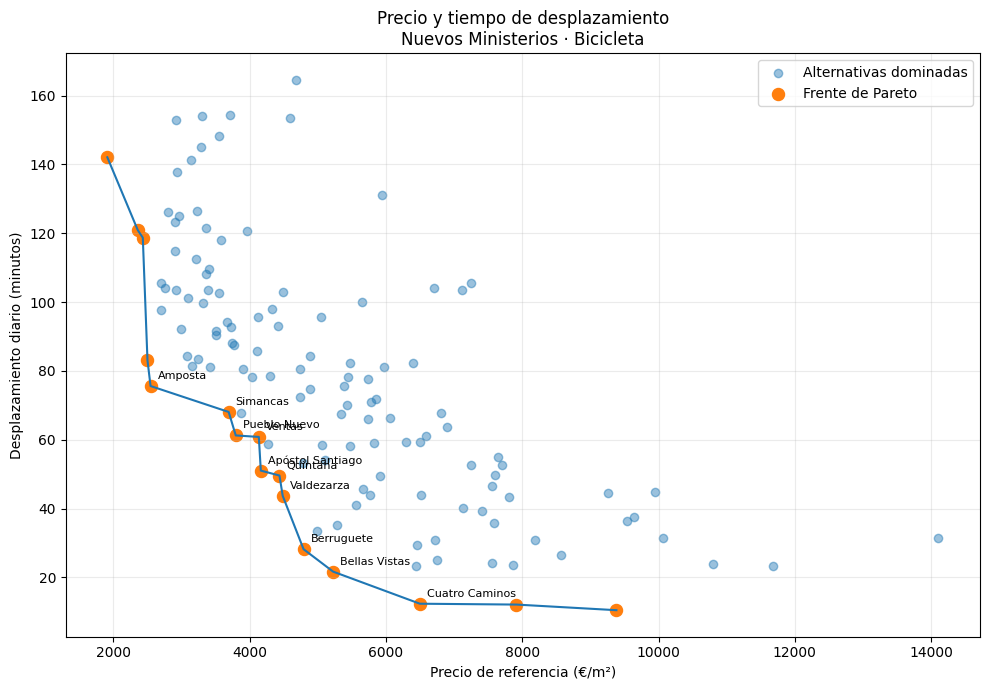

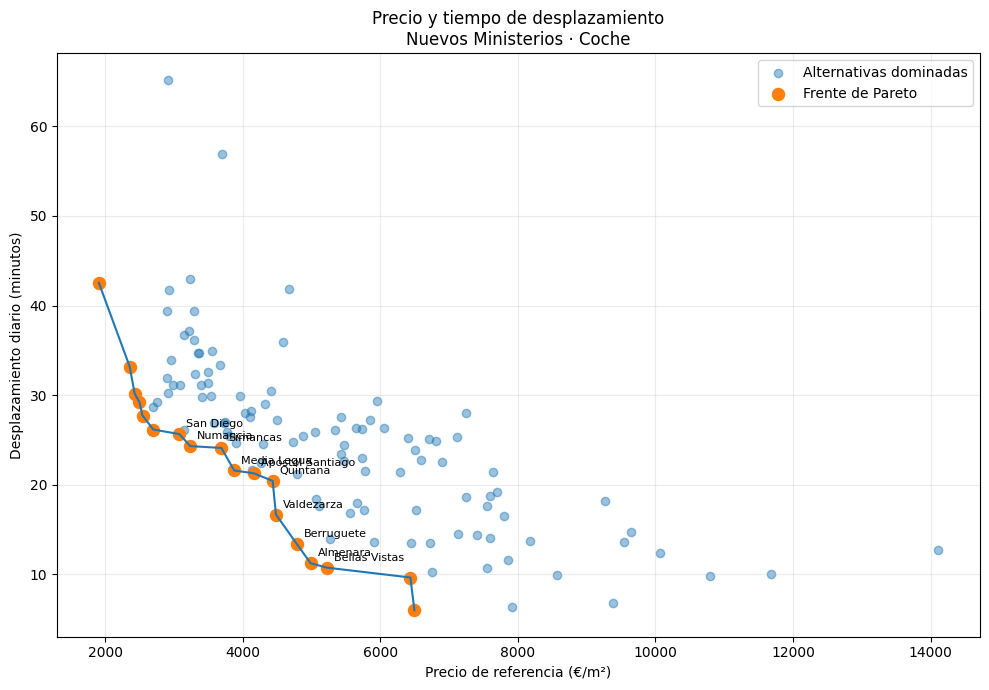

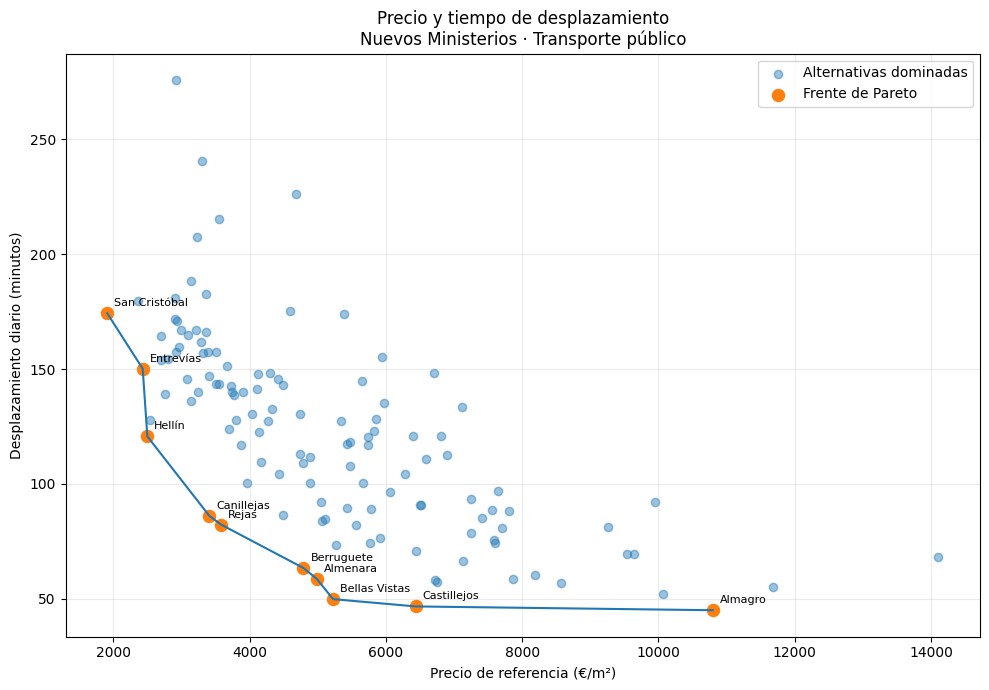

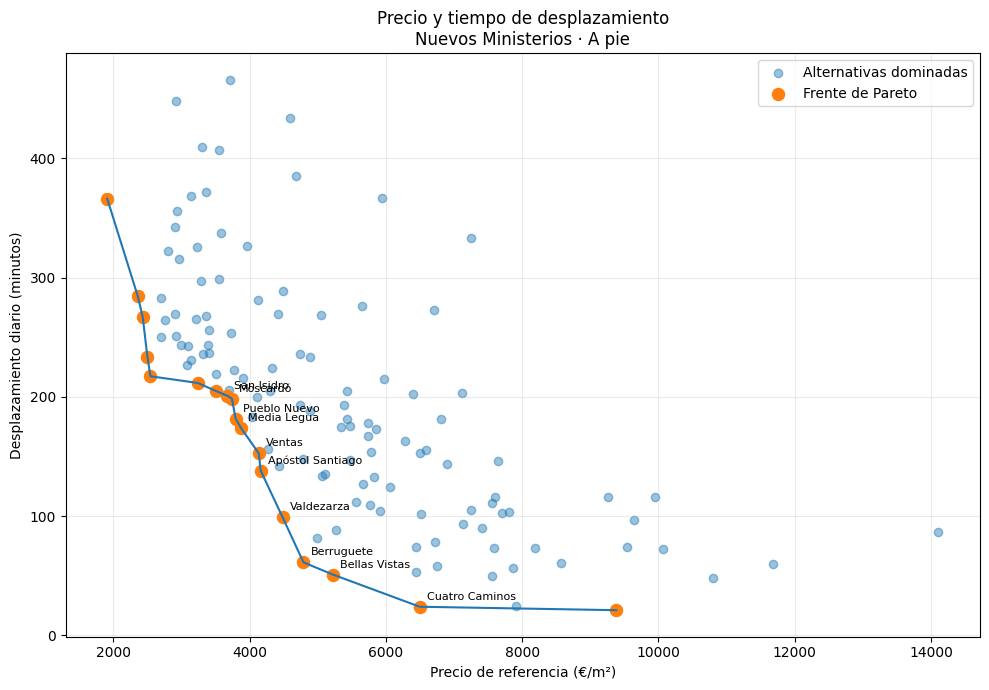

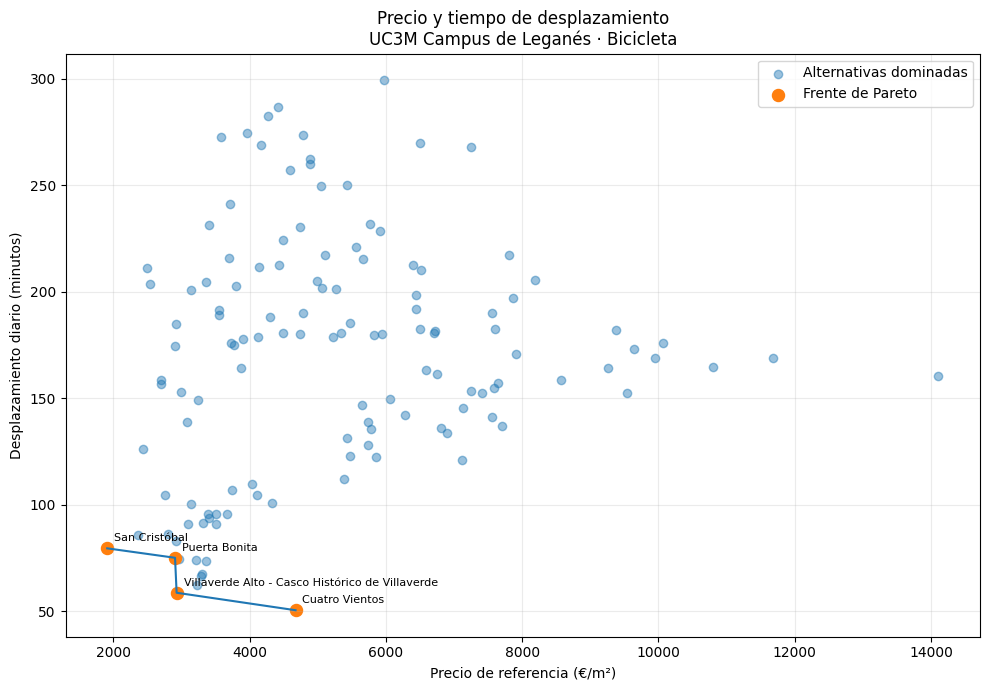

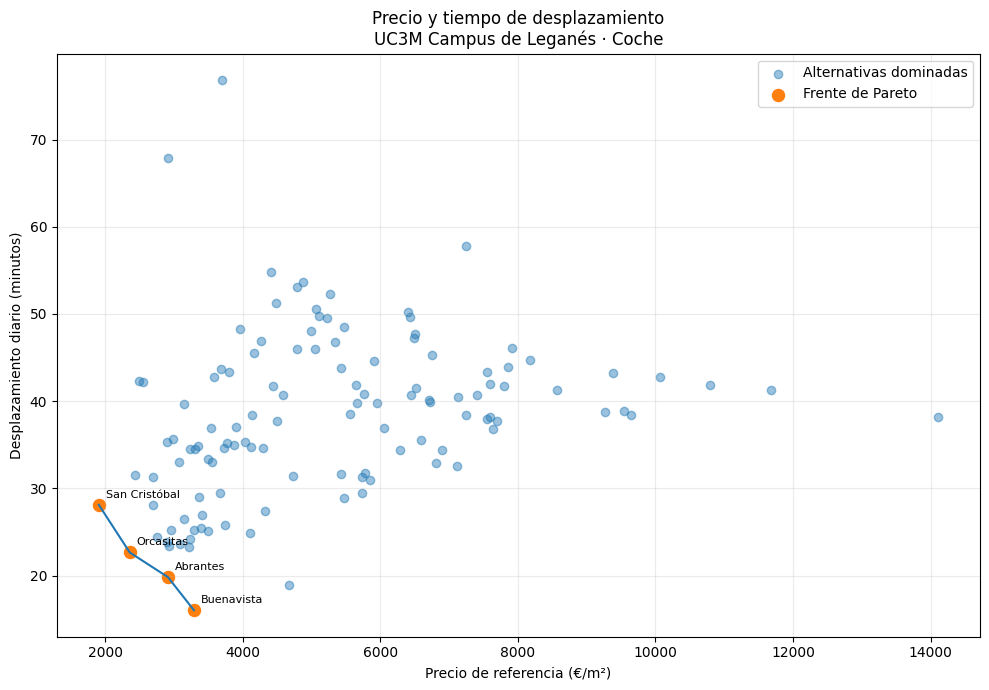

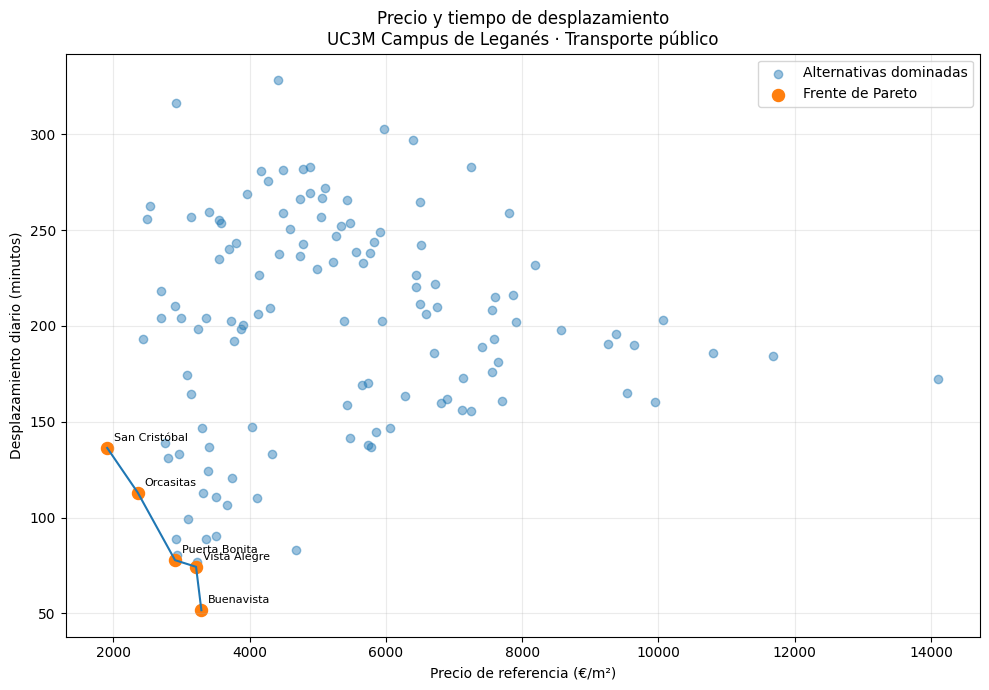

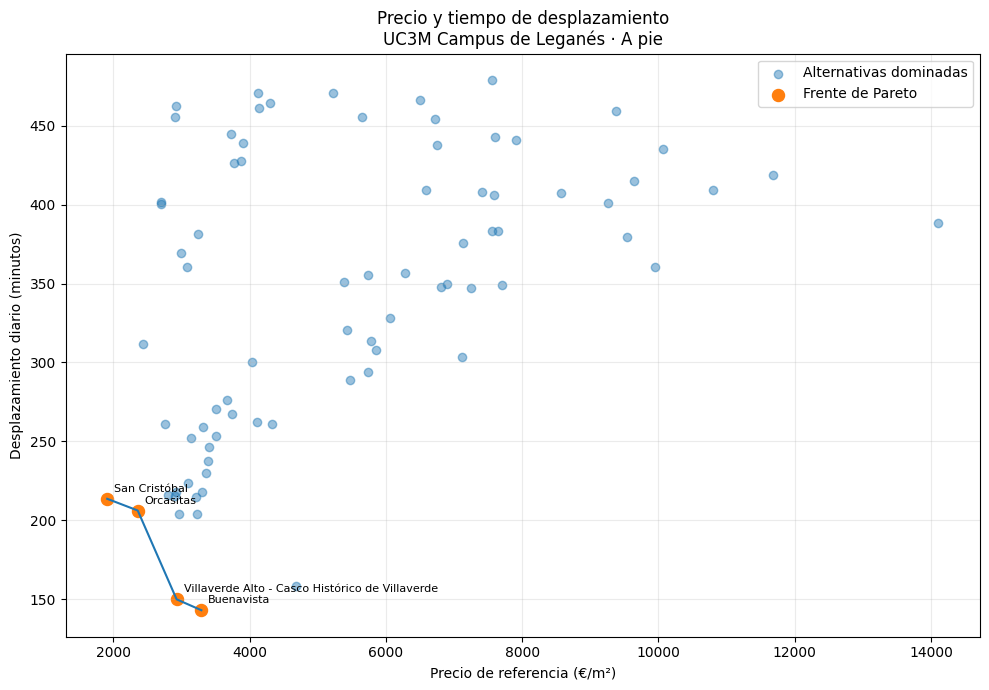

In [27]:
def plot_pareto_group(
    group: pd.DataFrame,
) -> None:
    """Representa las alternativas de un grupo destino-modo."""

    destination_name = (
        group[
            "destination_name"
        ]
        .dropna()
        .iloc[0]
    )

    transport_mode_label = (
        group[
            "transport_mode_label"
        ]
        .dropna()
        .iloc[0]
    )

    dominated = (
        group.loc[
            ~group[
                "is_pareto"
            ]
        ]
    )

    front = (
        group.loc[
            group[
                "is_pareto"
            ]
        ]
        .sort_values(
            [
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.scatter(
        dominated[
            PRICE_COLUMN
        ],
        dominated[
            TIME_COLUMN
        ],
        alpha=0.45,
        label="Alternativas dominadas",
    )

    plt.scatter(
        front[
            PRICE_COLUMN
        ],
        front[
            TIME_COLUMN
        ],
        s=75,
        label="Frente de Pareto",
    )

    plt.plot(
        front[
            PRICE_COLUMN
        ],
        front[
            TIME_COLUMN
        ],
        linewidth=1.5,
    )

    labels_to_show = (
        front.sort_values(
            [
                "distance_to_ideal",
                PRICE_COLUMN,
                TIME_COLUMN,
            ]
        )
        .head(10)
    )

    for _, row in (
        labels_to_show
        .iterrows()
    ):
        plt.annotate(
            row[
                "neighborhood_name"
            ],
            (
                row[
                    PRICE_COLUMN
                ],
                row[
                    TIME_COLUMN
                ],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel(
        "Precio de referencia (€/m²)"
    )

    plt.ylabel(
        "Desplazamiento diario (minutos)"
    )

    plt.title(
        "Precio y tiempo de desplazamiento\n"
        f"{destination_name} · {transport_mode_label}"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


for _, group in (
    pareto_results.groupby(
        PARETO_GROUP_KEY,
        sort=True,
    )
):
    plot_pareto_group(
        group
    )


## 10. Ejemplos de preferencias precio–tiempo

Pareto identifica alternativas eficientes, pero no establece un único ganador.

Como demostración se aplican tres combinaciones de pesos **dentro de cada frente destino–modo**:

- prioridad al precio: 75 % precio y 25 % tiempo;
- perfil equilibrado: 50 % precio y 50 % tiempo;
- prioridad al tiempo: 25 % precio y 75 % tiempo.

Estos pesos son ejemplos metodológicos. La personalización completa se realizará posteriormente con preferencias reales del usuario, incluyendo presupuesto, tiempo máximo, características de vivienda y modo de transporte.


In [28]:
PROFILE_WEIGHTS = {
    "price_priority": {
        "label":
            "Prioridad al precio",
        "price_weight":
            0.75,
        "time_weight":
            0.25,
    },

    "balanced": {
        "label":
            "Perfil equilibrado",
        "price_weight":
            0.50,
        "time_weight":
            0.50,
    },

    "time_priority": {
        "label":
            "Prioridad al tiempo",
        "price_weight":
            0.25,
        "time_weight":
            0.75,
    },
}


In [29]:
def build_profile_examples(
    results: pd.DataFrame,
) -> pd.DataFrame:
    """Selecciona una alternativa Pareto por perfil y grupo."""

    profile_rows = []

    for (
        destination_id,
        transport_mode,
    ), group in results.groupby(
        PARETO_GROUP_KEY,
        sort=True,
    ):
        front = (
            group.loc[
                group[
                    "is_pareto"
                ]
            ]
            .copy()
        )

        destination_name = (
            front[
                "destination_name"
            ]
            .dropna()
            .iloc[0]
        )

        transport_mode_label = (
            front[
                "transport_mode_label"
            ]
            .dropna()
            .iloc[0]
        )

        for (
            profile_id,
            profile,
        ) in PROFILE_WEIGHTS.items():
            scored_front = (
                front.copy()
            )

            scored_front[
                "profile_score"
            ] = (
                profile[
                    "price_weight"
                ]
                * scored_front[
                    "price_normalized"
                ]
                + profile[
                    "time_weight"
                ]
                * scored_front[
                    "time_normalized"
                ]
            )

            selected = (
                scored_front
                .sort_values(
                    [
                        "profile_score",
                        PRICE_COLUMN,
                        TIME_COLUMN,
                        "zone_key",
                    ]
                )
                .iloc[0]
            )

            profile_rows.append(
                {
                    "destination_id":
                        destination_id,

                    "destination_name":
                        destination_name,

                    "transport_mode":
                        transport_mode,

                    "transport_mode_label":
                        transport_mode_label,

                    "profile_id":
                        profile_id,

                    "profile_name":
                        profile[
                            "label"
                        ],

                    "price_weight":
                        profile[
                            "price_weight"
                        ],

                    "time_weight":
                        profile[
                            "time_weight"
                        ],

                    "zone_key":
                        selected[
                            "zone_key"
                        ],

                    "neighborhood_name":
                        selected[
                            "neighborhood_name"
                        ],

                    "district_name":
                        selected[
                            "district_name"
                        ],

                    "price_eur_m2":
                        round(
                            selected[
                                PRICE_COLUMN
                            ],
                            2,
                        ),

                    "commute_daily_minutes":
                        round(
                            selected[
                                TIME_COLUMN
                            ],
                            2,
                        ),

                    "profile_score":
                        round(
                            selected[
                                "profile_score"
                            ],
                            4,
                        ),
                }
            )

    return (
        pd.DataFrame(
            profile_rows
        )
        .sort_values(
            [
                "destination_id",
                "transport_mode",
                "profile_id",
            ]
        )
        .reset_index(drop=True)
    )


profile_examples = (
    build_profile_examples(
        pareto_results
    )
)

display(
    profile_examples
)


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,price_weight,time_weight,zone_key,neighborhood_name,district_name,price_eur_m2,commute_daily_minutes,profile_score
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,30.27,0.1607
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,Usera,2357.51,73.72,0.1246
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.25,0.75,MAD-016,Sol,Centro,7696.61,3.70,0.1186
3,DEST_001,Puerta del Sol,CAR,Coche,balanced,Perfil equilibrado,0.50,0.50,MAD-134,Palomeras Sureste,Puente de Vallecas,2701.36,24.37,0.1711
4,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,Usera,2357.51,28.42,0.1154
5,DEST_001,Puerta del Sol,CAR,Coche,time_priority,Prioridad al tiempo,0.25,0.75,MAD-015,Universidad,Centro,7135.43,10.00,0.1178
6,DEST_001,Puerta del Sol,TRANSIT,Transporte público,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,65.13,0.1103
7,DEST_001,Puerta del Sol,TRANSIT,Transporte público,price_priority,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,Villaverde,1909.60,139.72,0.1107
8,DEST_001,Puerta del Sol,TRANSIT,Transporte público,time_priority,Prioridad al tiempo,0.25,0.75,MAD-102,Puerta del Ángel,Latina,4033.30,65.13,0.0785
9,DEST_001,Puerta del Sol,WALK,A pie,balanced,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,Latina,4033.30,79.72,0.1750


### 10.1. Análisis de sensibilidad de los pesos

Para no depender únicamente de tres perfiles discretos, se varía el peso del precio entre 0 y 1 en incrementos de 0,05. El peso del tiempo toma el valor complementario.

El análisis permite identificar para qué intervalos de preferencias se mantiene una misma recomendación dentro de cada combinación destino–modo.


In [30]:
WEIGHT_GRID = np.round(
    np.linspace(
        0.0,
        1.0,
        21,
    ),
    2,
)

sensitivity_rows = []

for (
    destination_id,
    transport_mode,
), group in pareto_results.groupby(
    PARETO_GROUP_KEY,
    sort=True,
):
    front = (
        group.loc[
            group[
                "is_pareto"
            ]
        ]
        .copy()
    )

    destination_name = (
        front[
            "destination_name"
        ]
        .dropna()
        .iloc[0]
    )

    transport_mode_label = (
        front[
            "transport_mode_label"
        ]
        .dropna()
        .iloc[0]
    )

    for price_weight in (
        WEIGHT_GRID
    ):
        time_weight = round(
            1.0
            - price_weight,
            2,
        )

        scored_front = (
            front.copy()
        )

        scored_front[
            "sensitivity_score"
        ] = (
            price_weight
            * scored_front[
                "price_normalized"
            ]
            + time_weight
            * scored_front[
                "time_normalized"
            ]
        )

        selected = (
            scored_front
            .sort_values(
                [
                    "sensitivity_score",
                    PRICE_COLUMN,
                    TIME_COLUMN,
                    "zone_key",
                ]
            )
            .iloc[0]
        )

        sensitivity_rows.append(
            {
                "destination_id":
                    destination_id,

                "destination_name":
                    destination_name,

                "transport_mode":
                    transport_mode,

                "transport_mode_label":
                    transport_mode_label,

                "price_weight":
                    price_weight,

                "time_weight":
                    time_weight,

                "zone_key":
                    selected[
                        "zone_key"
                    ],

                "neighborhood_name":
                    selected[
                        "neighborhood_name"
                    ],

                "district_name":
                    selected[
                        "district_name"
                    ],

                "price_eur_m2":
                    round(
                        selected[
                            PRICE_COLUMN
                        ],
                        2,
                    ),

                "commute_daily_minutes":
                    round(
                        selected[
                            TIME_COLUMN
                        ],
                        2,
                    ),

                "sensitivity_score":
                    round(
                        selected[
                            "sensitivity_score"
                        ],
                        4,
                    ),
            }
        )

weight_sensitivity = (
    pd.DataFrame(
        sensitivity_rows
    )
    .sort_values(
        [
            "destination_id",
            "transport_mode",
            "price_weight",
        ]
    )
    .reset_index(drop=True)
)

weight_sensitivity[
    "selection_block"
] = (
    weight_sensitivity
    .groupby(
        PARETO_GROUP_KEY
    )[
        "zone_key"
    ]
    .transform(
        lambda values:
            values.ne(
                values.shift()
            )
            .cumsum()
    )
)

weight_sensitivity_summary = (
    weight_sensitivity
    .groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
            "selection_block",
            "zone_key",
            "neighborhood_name",
            "district_name",
        ],
        as_index=False,
    )
    .agg(
        minimum_price_weight=(
            "price_weight",
            "min",
        ),
        maximum_price_weight=(
            "price_weight",
            "max",
        ),
        evaluated_weights=(
            "price_weight",
            "size",
        ),
        price_eur_m2=(
            "price_eur_m2",
            "first",
        ),
        commute_daily_minutes=(
            "commute_daily_minutes",
            "first",
        ),
    )
    .drop(
        columns=[
            "selection_block"
        ]
    )
)

display(
    weight_sensitivity_summary
)


,destination_id,destination_name,transport_mode,transport_mode_label,zone_key,neighborhood_name,district_name,minimum_price_weight,maximum_price_weight,evaluated_weights,price_eur_m2,commute_daily_minutes
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,MAD-016,Sol,Centro,0.00,0.30,7,7696.61,3.70
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,MAD-102,Puerta del Ángel,Latina,0.35,0.55,5,4033.30,30.27
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,MAD-123,San Fermín,Usera,0.60,0.70,3,2755.18,56.98
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,MAD-121,Orcasitas,Usera,0.75,0.75,1,2357.51,73.72
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,MAD-172,San Cristóbal,Villaverde,0.80,1.00,5,1909.60,94.93
5,DEST_001,Puerta del Sol,CAR,Coche,MAD-014,Justicia,Centro,0.00,0.05,2,9541.90,9.22
6,DEST_001,Puerta del Sol,CAR,Coche,MAD-015,Universidad,Centro,0.10,0.40,7,7135.43,10.00
7,DEST_001,Puerta del Sol,CAR,Coche,MAD-144,Media Legua,Moratalaz,0.45,0.45,1,3876.72,20.02
8,DEST_001,Puerta del Sol,CAR,Coche,MAD-134,Palomeras Sureste,Puente de Vallecas,0.50,0.70,5,2701.36,24.37
9,DEST_001,Puerta del Sol,CAR,Coche,MAD-121,Orcasitas,Usera,0.75,0.85,3,2357.51,28.42


## 11. Accesibilidad general por modo

Como análisis complementario se resume, para cada barrio y **cada modo**, el tiempo diario medio y el peor tiempo observado considerando todos los destinos.

Solo se incluyen barrios con ruta utilizable hacia **todos los destinos** en ese modo. De esta forma no se favorece artificialmente a una zona porque falten precisamente los trayectos más difíciles.

El resultado es una medida exploratoria de accesibilidad general. No sustituye la recomendación personalizada por destino.


In [31]:
number_of_destinations = (
    pareto_base[
        "destination_id"
    ]
    .nunique()
)

global_zone_mode_data = (
    pareto_base
    .groupby(
        [
            "zone_key",
            "neighborhood_name",
            "district_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        price_m2_for_recommender=(
            PRICE_COLUMN,
            "first",
        ),

        destinations_with_complete_route=(
            "destination_id",
            "nunique",
        ),

        average_commute_daily_minutes=(
            TIME_COLUMN,
            "mean",
        ),

        worst_commute_daily_minutes=(
            TIME_COLUMN,
            "max",
        ),
    )
)

global_zone_mode_data = (
    global_zone_mode_data.loc[
        global_zone_mode_data[
            "destinations_with_complete_route"
        ].eq(
            number_of_destinations
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Destinos utilizados:",
    number_of_destinations,
)

print(
    "Combinaciones barrio-modo "
    "con ruta completa a todos los destinos:",
    len(global_zone_mode_data),
)


Destinos utilizados: 3
Combinaciones barrio-modo con ruta completa a todos los destinos: 444


In [32]:
def calculate_global_pareto_by_mode(
    data: pd.DataFrame,
) -> pd.DataFrame:
    """Calcula Pareto global por modo usando precio y tiempo medio."""

    result_parts = []

    for transport_mode, group in (
        data.groupby(
            "transport_mode",
            sort=True,
        )
    ):
        group = group.copy()

        objectives = group[
            [
                PRICE_COLUMN,
                "average_commute_daily_minutes",
            ]
        ].to_numpy(
            dtype=float
        )

        group[
            "is_pareto_global"
        ] = pareto_mask_minimization(
            objectives
        )

        group[
            "dominated_by_count_global"
        ] = count_dominators(
            objectives
        )

        group[
            "price_normalized_global"
        ] = min_max_normalize(
            group[
                PRICE_COLUMN
            ]
        )

        group[
            "average_time_normalized_global"
        ] = min_max_normalize(
            group[
                "average_commute_daily_minutes"
            ]
        )

        group[
            "distance_to_ideal_global"
        ] = np.sqrt(
            group[
                "price_normalized_global"
            ] ** 2
            + group[
                "average_time_normalized_global"
            ] ** 2
        )

        result_parts.append(
            group
        )

    return (
        pd.concat(
            result_parts,
            ignore_index=True,
        )
    )


global_zone_mode_data = (
    calculate_global_pareto_by_mode(
        global_zone_mode_data
    )
)

global_front = (
    global_zone_mode_data.loc[
        global_zone_mode_data[
            "is_pareto_global"
        ]
    ]
    .copy()
    .sort_values(
        [
            "transport_mode",
            PRICE_COLUMN,
            "average_commute_daily_minutes",
        ]
    )
    .reset_index(drop=True)
)

display(
    global_front[
        [
            "transport_mode",
            "transport_mode_label",
            "zone_key",
            "neighborhood_name",
            "district_name",
            PRICE_COLUMN,
            "average_commute_daily_minutes",
            "worst_commute_daily_minutes",
            "distance_to_ideal_global",
        ]
    ]
    .round(2)
)


,transport_mode,transport_mode_label,zone_key,neighborhood_name,district_name,price_m2_for_recommender,average_commute_daily_minutes,worst_commute_daily_minutes,distance_to_ideal_global
0,BICYCLE,Bicicleta,MAD-172,San Cristóbal,Villaverde,1909.60,105.51,142.07,0.31
1,BICYCLE,Bicicleta,MAD-121,Orcasitas,Usera,2357.51,93.53,120.87,0.22
2,BICYCLE,Bicicleta,MAD-123,San Fermín,Usera,2755.18,88.60,104.68,0.20
3,BICYCLE,Bicicleta,MAD-115,Puerta Bonita,Carabanchel,2905.06,85.98,114.98,0.18
4,BICYCLE,Bicicleta,MAD-117,Abrantes,Carabanchel,2912.90,80.91,103.40,0.15
5,BICYCLE,Bicicleta,MAD-112,Opañel,Carabanchel,3500.89,74.84,90.92,0.15
6,BICYCLE,Bicicleta,MAD-102,Puerta del Ángel,Latina,4033.30,72.71,109.68,0.18
7,BICYCLE,Bicicleta,MAD-011,Palacio,Centro,6895.15,71.03,133.70,0.41
8,BICYCLE,Bicicleta,MAD-015,Universidad,Centro,7135.43,67.59,145.28,0.43
9,BICYCLE,Bicicleta,MAD-016,Sol,Centro,7696.61,64.50,137.12,0.47


In [33]:
for (
    transport_mode,
    transport_mode_label,
), group in global_front.groupby(
    [
        "transport_mode",
        "transport_mode_label",
    ],
    sort=True,
):
    balanced_global = (
        group.sort_values(
            [
                "distance_to_ideal_global",
                PRICE_COLUMN,
                "average_commute_daily_minutes",
                "zone_key",
            ]
        )
        .iloc[0]
    )

    display(
        Markdown(
            f"""
### Accesibilidad general · {transport_mode_label}

El frente global de este modo contiene **{len(group)} barrios** con rutas utilizables hacia los {number_of_destinations} destinos.

La referencia más próxima al punto ideal es **{balanced_global['neighborhood_name']}**, con **{balanced_global[PRICE_COLUMN]:,.2f} €/m²** y un desplazamiento diario medio de **{balanced_global['average_commute_daily_minutes']:.2f} minutos**.

Este indicador resume accesibilidad general; para una decisión real debe prevalecer el destino y el modo que corresponden a la rutina del usuario.
"""
        )
    )



### Accesibilidad general · Bicicleta

El frente global de este modo contiene **10 barrios** con rutas utilizables hacia los 3 destinos.

La referencia más próxima al punto ideal es **Abrantes**, con **2,912.90 €/m²** y un desplazamiento diario medio de **80.91 minutos**.

Este indicador resume accesibilidad general; para una decisión real debe prevalecer el destino y el modo que corresponden a la rutina del usuario.



### Accesibilidad general · Coche

El frente global de este modo contiene **11 barrios** con rutas utilizables hacia los 3 destinos.

La referencia más próxima al punto ideal es **Abrantes**, con **2,912.90 €/m²** y un desplazamiento diario medio de **25.08 minutos**.

Este indicador resume accesibilidad general; para una decisión real debe prevalecer el destino y el modo que corresponden a la rutina del usuario.



### Accesibilidad general · Transporte público

El frente global de este modo contiene **8 barrios** con rutas utilizables hacia los 3 destinos.

La referencia más próxima al punto ideal es **Opañel**, con **3,500.89 €/m²** y un desplazamiento diario medio de **105.88 minutos**.

Este indicador resume accesibilidad general; para una decisión real debe prevalecer el destino y el modo que corresponden a la rutina del usuario.



### Accesibilidad general · A pie

El frente global de este modo contiene **14 barrios** con rutas utilizables hacia los 3 destinos.

La referencia más próxima al punto ideal es **Opañel**, con **3,500.89 €/m²** y un desplazamiento diario medio de **187.81 minutos**.

Este indicador resume accesibilidad general; para una decisión real debe prevalecer el destino y el modo que corresponden a la rutina del usuario.


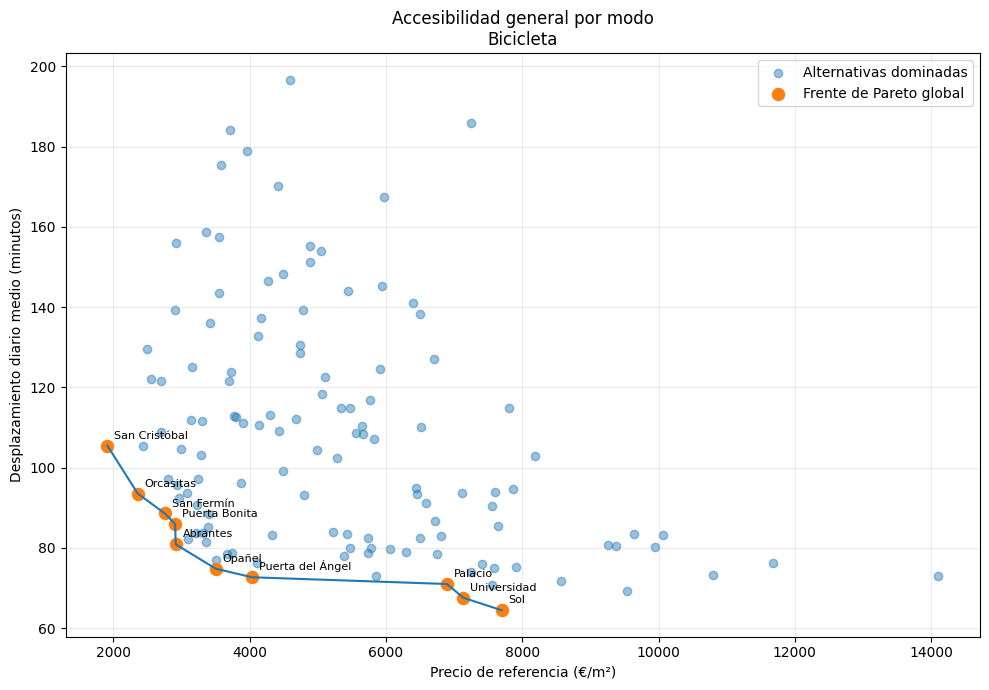

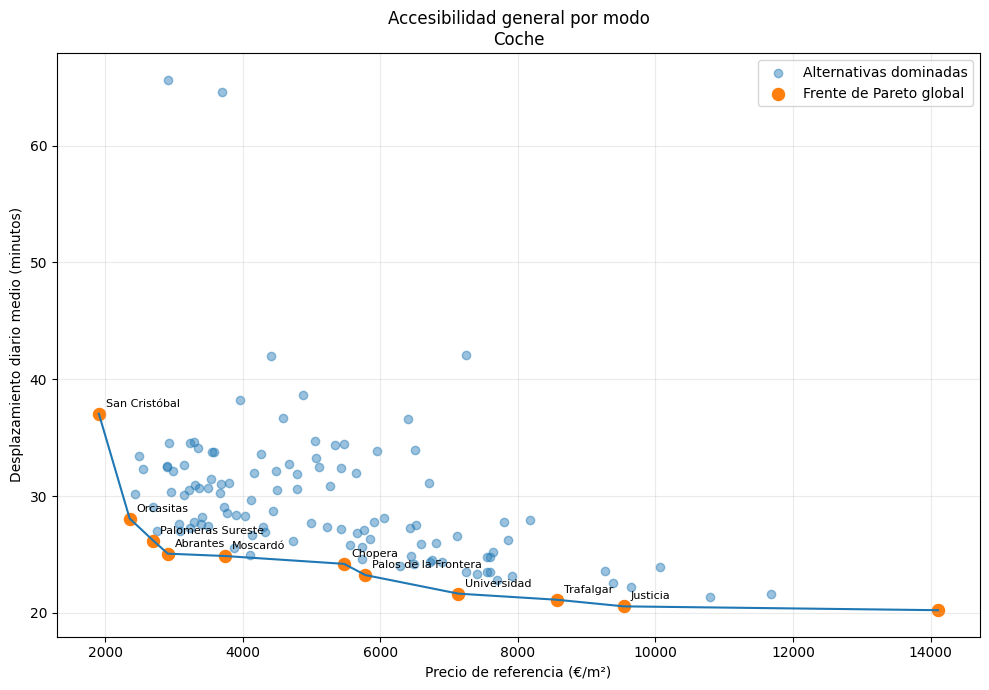

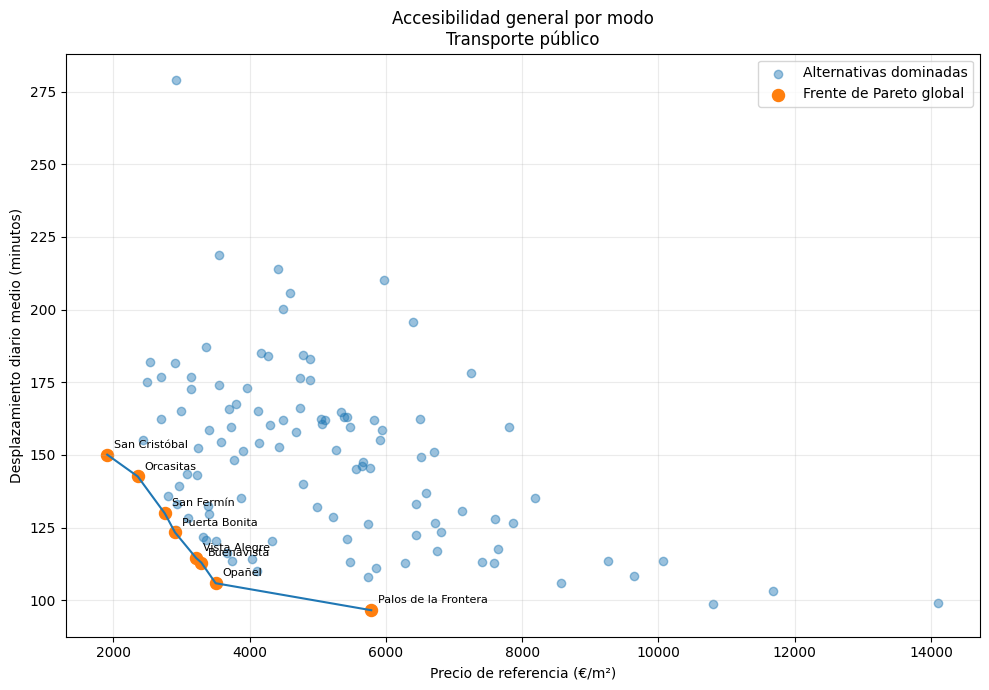

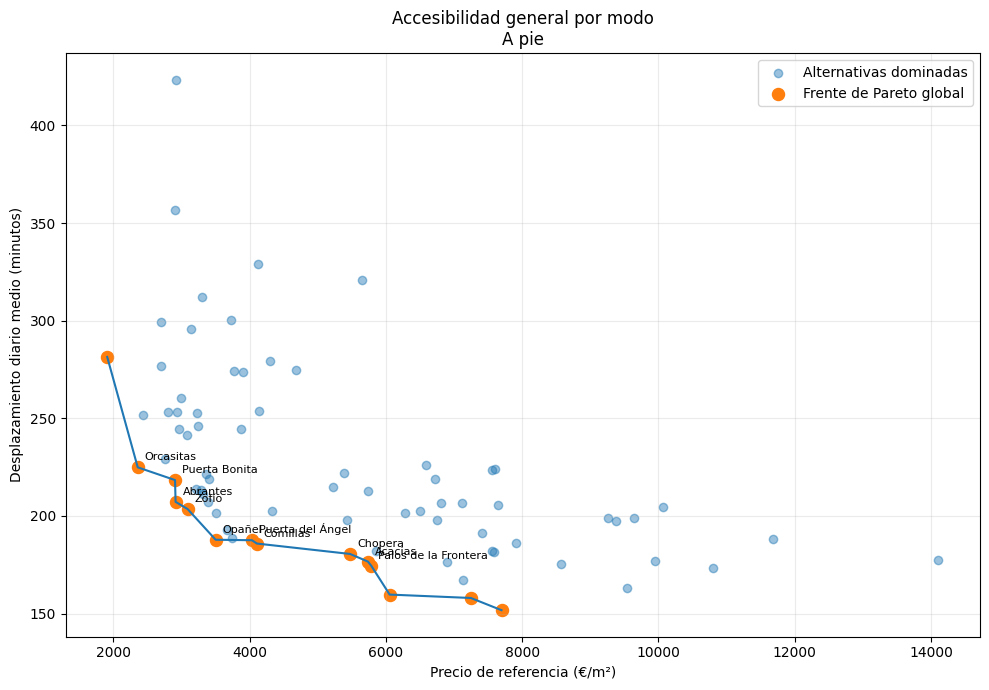

In [34]:
def plot_global_mode(
    group: pd.DataFrame,
) -> None:
    transport_mode_label = (
        group[
            "transport_mode_label"
        ]
        .dropna()
        .iloc[0]
    )

    dominated = (
        group.loc[
            ~group[
                "is_pareto_global"
            ]
        ]
    )

    front = (
        group.loc[
            group[
                "is_pareto_global"
            ]
        ]
        .sort_values(
            [
                PRICE_COLUMN,
                "average_commute_daily_minutes",
            ]
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.scatter(
        dominated[
            PRICE_COLUMN
        ],
        dominated[
            "average_commute_daily_minutes"
        ],
        alpha=0.45,
        label="Alternativas dominadas",
    )

    plt.scatter(
        front[
            PRICE_COLUMN
        ],
        front[
            "average_commute_daily_minutes"
        ],
        s=75,
        label="Frente de Pareto global",
    )

    plt.plot(
        front[
            PRICE_COLUMN
        ],
        front[
            "average_commute_daily_minutes"
        ],
        linewidth=1.5,
    )

    for _, row in (
        front.sort_values(
            "distance_to_ideal_global"
        )
        .head(10)
        .iterrows()
    ):
        plt.annotate(
            row[
                "neighborhood_name"
            ],
            (
                row[
                    PRICE_COLUMN
                ],
                row[
                    "average_commute_daily_minutes"
                ],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel(
        "Precio de referencia (€/m²)"
    )

    plt.ylabel(
        "Desplazamiento diario medio (minutos)"
    )

    plt.title(
        "Accesibilidad general por modo\n"
        f"{transport_mode_label}"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


for _, group in (
    global_zone_mode_data.groupby(
        "transport_mode",
        sort=True,
    )
):
    plot_global_mode(
        group
    )


## 12. Guardado de resultados

Se guardan archivos específicos de la versión multimodal:

- `pareto_by_destination_mode.csv`: todas las alternativas utilizadas, con indicadores de dominancia.
- `pareto_front_by_destination_mode.csv`: únicamente las alternativas no dominadas.
- `pareto_summary_by_destination_mode.csv`: resumen por destino y modo.
- `pareto_global_accessibility_by_mode.csv`: accesibilidad general calculada por modo.
- `pareto_profile_examples_by_destination_mode.csv`: ejemplos de prioridades precio–tiempo.
- `pareto_marginal_tradeoffs_by_destination_mode.csv`: intercambio marginal a lo largo de cada frente.
- `pareto_weight_sensitivity_by_destination_mode.csv`: sensibilidad continua a los pesos.
- `pareto_mode_comparison_summary.csv`: comparación descriptiva de tiempos y tamaños de frente entre modos.

Los nombres incluyen explícitamente el modo para evitar confundir estos resultados con los generados por la versión anterior basada solo en transporte público.


In [35]:
pareto_results.to_csv(
    PARETO_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig",
)

pareto_front.to_csv(
    PARETO_FRONT_PATH,
    index=False,
    encoding="utf-8-sig",
)

pareto_summary.to_csv(
    PARETO_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

global_zone_mode_data.to_csv(
    PARETO_GLOBAL_PATH,
    index=False,
    encoding="utf-8-sig",
)

profile_examples.to_csv(
    PARETO_PROFILES_PATH,
    index=False,
    encoding="utf-8-sig",
)

marginal_tradeoffs.to_csv(
    PARETO_TRADEOFF_PATH,
    index=False,
    encoding="utf-8-sig",
)

weight_sensitivity.to_csv(
    PARETO_SENSITIVITY_PATH,
    index=False,
    encoding="utf-8-sig",
)

mode_comparison_summary.to_csv(
    PARETO_MODE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(
    "Archivos generados:"
)

for path in [
    PARETO_RESULTS_PATH,
    PARETO_FRONT_PATH,
    PARETO_SUMMARY_PATH,
    PARETO_GLOBAL_PATH,
    PARETO_PROFILES_PATH,
    PARETO_TRADEOFF_PATH,
    PARETO_SENSITIVITY_PATH,
    PARETO_MODE_SUMMARY_PATH,
]:
    print(
        "-",
        path.relative_to(
            PROJECT_ROOT
        ),
    )


Archivos generados:
- data\results\pareto_by_destination_mode.csv
- data\results\pareto_front_by_destination_mode.csv
- data\results\pareto_summary_by_destination_mode.csv
- data\results\pareto_global_accessibility_by_mode.csv
- data\results\pareto_profile_examples_by_destination_mode.csv
- data\results\pareto_marginal_tradeoffs_by_destination_mode.csv
- data\results\pareto_weight_sensitivity_by_destination_mode.csv
- data\results\pareto_mode_comparison_summary.csv


## 13. Validaciones finales

Antes de cerrar el notebook se verifican propiedades estructurales y matemáticas:

- todas las alternativas Pareto tienen cero dominadores;
- ninguna alternativa dominada tiene cero dominadores;
- todos los grupos destino–modo tienen al menos una alternativa Pareto;
- las claves `barrio–destino–modo` permanecen completas y únicas;
- las recomendaciones de perfiles y sensibilidad pertenecen al frente correspondiente;
- se evalúan exactamente 21 combinaciones de pesos por cada grupo destino–modo;
- los frentes ordenados por precio no presentan aumentos de tiempo incompatibles con la no dominancia;
- el análisis global se realiza independientemente por modo;
- ningún resultado mezcla alternativas de diferentes medios de transporte dentro del mismo frente.


In [36]:
# Pareto <-> número de dominadores.

assert (
    pareto_results.loc[
        pareto_results[
            "is_pareto"
        ],
        "dominated_by_count",
    ]
    .eq(0)
    .all()
), (
    "Alguna alternativa Pareto aparece dominada."
)

assert (
    pareto_results.loc[
        ~pareto_results[
            "is_pareto"
        ],
        "dominated_by_count",
    ]
    .gt(0)
    .all()
), (
    "Alguna alternativa no Pareto aparece sin dominadores."
)


In [37]:
# Cobertura de grupos y unicidad de claves.

pareto_count_by_group = (
    pareto_results
    .groupby(
        PARETO_GROUP_KEY
    )[
        "is_pareto"
    ]
    .sum()
)

assert (
    pareto_count_by_group
    .gt(0)
    .all()
), (
    "Algún grupo destino-modo no tiene alternativas Pareto."
)

assert not pareto_results.duplicated(
    subset=ALTERNATIVE_KEY
).any(), (
    "Pareto contiene alternativas barrio-destino-modo duplicadas."
)

assert (
    pareto_results[
        [
            "zone_key",
            "destination_id",
            "transport_mode",
        ]
    ]
    .notna()
    .all()
    .all()
), (
    "Faltan claves en los resultados de Pareto."
)


In [38]:
# Validación de recomendaciones por perfil.

pareto_key_triples = set(
    map(
        tuple,
        pareto_front[
            [
                "destination_id",
                "transport_mode",
                "zone_key",
            ]
        ]
        .itertuples(
            index=False,
            name=None,
        ),
    )
)

profile_key_triples = set(
    map(
        tuple,
        profile_examples[
            [
                "destination_id",
                "transport_mode",
                "zone_key",
            ]
        ]
        .itertuples(
            index=False,
            name=None,
        ),
    )
)

assert profile_key_triples.issubset(
    pareto_key_triples
), (
    "Algún perfil ha seleccionado una alternativa "
    "fuera de su frente de Pareto."
)

expected_profile_rows = (
    len(
        pareto_results[
            PARETO_GROUP_KEY
        ]
        .drop_duplicates()
    )
    * len(
        PROFILE_WEIGHTS
    )
)

assert (
    len(profile_examples)
    == expected_profile_rows
), (
    "No se ha generado exactamente una recomendación "
    "por perfil y grupo destino-modo."
)


In [39]:
# Validación del análisis de sensibilidad.

assert np.isclose(
    weight_sensitivity[
        "price_weight"
    ]
    + weight_sensitivity[
        "time_weight"
    ],
    1.0,
).all(), (
    "Alguna combinación de pesos no suma 1."
)

expected_weight_evaluations = (
    len(
        WEIGHT_GRID
    )
)

assert (
    weight_sensitivity
    .groupby(
        PARETO_GROUP_KEY
    )
    .size()
    .eq(
        expected_weight_evaluations
    )
    .all()
), (
    "No se han evaluado exactamente "
    "21 pesos en todos los grupos destino-modo."
)

sensitivity_key_triples = set(
    map(
        tuple,
        weight_sensitivity[
            [
                "destination_id",
                "transport_mode",
                "zone_key",
            ]
        ]
        .itertuples(
            index=False,
            name=None,
        ),
    )
)

assert sensitivity_key_triples.issubset(
    pareto_key_triples
), (
    "El análisis de sensibilidad ha seleccionado "
    "una alternativa fuera de su frente de Pareto."
)


In [40]:
# Validación de los trade-offs marginales.

valid_tradeoff_rows = (
    marginal_tradeoffs[
        "extra_price_eur_m2_vs_previous"
    ]
    .notna()
)

price_diffs = (
    marginal_tradeoffs.loc[
        valid_tradeoff_rows,
        "extra_price_eur_m2_vs_previous",
    ]
)

time_savings = (
    marginal_tradeoffs.loc[
        valid_tradeoff_rows,
        "daily_minutes_saved_vs_previous",
    ]
)

assert (
    price_diffs
    .ge(-1e-9)
    .all()
), (
    "Algún frente no está correctamente ordenado por precio."
)

assert (
    time_savings
    .ge(-1e-9)
    .all()
), (
    "Al avanzar hacia una alternativa más cara "
    "aparece un aumento del tiempo incompatible "
    "con un frente de Pareto correctamente construido."
)


In [41]:
# Validación del análisis global por modo.

assert not global_zone_mode_data.duplicated(
    subset=[
        "zone_key",
        "transport_mode",
    ]
).any(), (
    "El análisis global contiene combinaciones barrio-modo duplicadas."
)

assert (
    global_zone_mode_data[
        "destinations_with_complete_route"
    ]
    .eq(
        number_of_destinations
    )
    .all()
), (
    "El análisis global contiene barrios sin cobertura "
    "completa de destinos."
)

assert (
    global_zone_mode_data.loc[
        global_zone_mode_data[
            "is_pareto_global"
        ],
        "dominated_by_count_global",
    ]
    .eq(0)
    .all()
), (
    "Alguna alternativa Pareto global aparece dominada."
)

assert (
    global_zone_mode_data
    .groupby(
        "transport_mode"
    )[
        "is_pareto_global"
    ]
    .sum()
    .gt(0)
    .all()
), (
    "Algún modo no tiene frente de Pareto global."
)


In [42]:
print(
    "Todas las validaciones del análisis "
    "de Pareto multimodal se han superado correctamente."
)


Todas las validaciones del análisis de Pareto multimodal se han superado correctamente.


## 14. Conclusiones

El análisis demuestra que la accesibilidad residencial no depende únicamente del barrio y del destino, sino también del **medio de transporte** utilizado.

La extensión multimodal se incorpora sin alterar la formulación principal del problema: Pareto continúa minimizando **precio de vivienda** y **tiempo diario de desplazamiento**, pero los frentes se calculan de manera independiente para cada combinación destino–modo. Así se evita mezclar alternativas de movilidad diferentes dentro de un mismo problema de dominancia.

Para cada frente se identifican:

1. alternativas dominadas y no dominadas;
2. una referencia equilibrada mediante distancia normalizada al punto ideal;
3. el coste marginal de reducir tiempo a cambio de un mayor precio;
4. recomendaciones ilustrativas para distintas prioridades;
5. la sensibilidad de la selección ante cambios progresivos en los pesos.

También se calcula una medida complementaria de accesibilidad general **por modo**, utilizando únicamente barrios con cobertura completa hacia todos los destinos.

### Interpretación metodológica

La pertenencia al frente de Pareto no depende de los pesos ni de la normalización. Los pesos se utilizan únicamente después de obtener el frente para ilustrar preferencias. Por tanto, el análisis separa correctamente:

- **eficiencia multiobjetivo**: determinada por dominancia;
- **preferencia del usuario**: aplicada posteriormente sobre alternativas eficientes.

### Limitaciones

Los precios son valores de referencia por metro cuadrado y no tasaciones de viviendas concretas. La conversión a una vivienda de 80 m² es solo orientativa.

Los tiempos proceden del routing calculado en el notebook 06. Cada barrio se representa mediante una coordenada y los resultados dependen de la fecha, horarios, red y datos disponibles. En particular, el coche no incorpora tráfico en tiempo real y los recorridos a pie o en bicicleta dependen de la representación de la red en OpenStreetMap.

Las rutas parciales y los casos `no_route` permanecen documentados en el dataset completo, pero se excluyen de Pareto porque no permiten una comparación homogénea de tiempo.

Finalmente, el análisis por pesos sigue siendo una simplificación. La recomendación final debe incorporar restricciones personales como presupuesto, características de vivienda, tiempo máximo y **modo de transporte seleccionado por el usuario**, que se abordarán en los siguientes notebooks.


In [43]:
final_summary = pd.Series(
    {
        "rows_received_model_ready":
            len(
                model_data
            ),

        "rows_used_in_pareto":
            len(
                pareto_results
            ),

        "neighborhoods_analyzed":
            pareto_results[
                "zone_key"
            ].nunique(),

        "destinations_analyzed":
            pareto_results[
                "destination_id"
            ].nunique(),

        "transport_modes_analyzed":
            pareto_results[
                "transport_mode"
            ].nunique(),

        "destination_mode_groups":
            len(
                pareto_results[
                    PARETO_GROUP_KEY
                ]
                .drop_duplicates()
            ),

        "pareto_rows":
            len(
                pareto_front
            ),

        "global_zone_mode_rows":
            len(
                global_zone_mode_data
            ),

        "global_pareto_rows":
            len(
                global_front
            ),

        "profile_recommendations":
            len(
                profile_examples
            ),

        "weight_sensitivity_rows":
            len(
                weight_sensitivity
            ),

        "unique_sensitivity_recommendations":
            (
                weight_sensitivity[
                    [
                        "destination_id",
                        "transport_mode",
                        "zone_key",
                    ]
                ]
                .drop_duplicates()
                .shape[0]
            ),

        "marginal_tradeoff_rows":
            len(
                marginal_tradeoffs
            ),
    },
    name="value",
)

display(
    final_summary.to_frame()
)

print(
    "\nNotebook 08 multimodal finalizado correctamente."
)


,value
rows_received_model_ready,1457
rows_used_in_pareto,1457
neighborhoods_analyzed,129
destinations_analyzed,3
transport_modes_analyzed,4
destination_mode_groups,12
pareto_rows,136
global_zone_mode_rows,444
global_pareto_rows,43
profile_recommendations,36



Notebook 08 multimodal finalizado correctamente.
